# $\color{cyan}{\text{Imports and Setup}}$

## $\color{yellow}{\text{Imports}}$

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit
import seaborn as sns
from scipy.stats import linregress
import re
import plotly.graph_objects as go
import ipywidgets as widgets

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

from scripts.sync import run_sync
from scripts.data_loader import load_titan_data
from scripts.setup_functions import run_pel_analysis, run_immob_analysis, run_standard_curve_analysis, four_pl, five_pl
from scripts.analysis_functions import analyse_pel, analyse_immob_split, plot_pel_layer_shifts, combine_anomalies, analyse_cross_stage_split, cross_stage_correlations, create_interactive_dashboard, generate_at_risk_summary, prepare_section

## $\color{yellow}{\text{Setup}}$

In [3]:
# Show all dataframe columns
pd.set_option('display.max_columns', None)

### $\color{gold}{\text{Database Loading}}$

In [4]:
# Only need to run to download datasets
#run_sync()

In [5]:
tables, bucket_data = load_titan_data()

Loading database tables...
Loading table: amf_turns
Loading table: backend_event_log
Loading table: backend_event_log_archive
EMPTY FILE SKIPPED: backend_event_log_archive.csv
Loading table: chip_calibrations
Loading table: chip_calibration_spetrca
Loading table: chip_labelling
EMPTY FILE SKIPPED: chip_labelling.csv
Loading table: chip_status
Loading table: comments
Loading table: device
Loading table: experiments
Loading table: experiment_chips
Loading table: experiment_standard_curves
Loading table: flagged_items
Loading table: flags
Loading table: immob
Loading table: machine
Loading table: measurements
Loading table: notifications
Loading table: optical_reference_spectra
Loading table: pel_upload
Loading table: qc_baseline_drift
Loading table: qc_measurements
Loading table: sensorgram_history
Loading table: standard_curves
Loading table: standard_curve_history
Loading table: system_utilization_log
Loading table: uploads
Loading table: users
Loading and filtering bucket data...
SKIP

### $\color{gold}{\text{Fixing Flags}}$

In [6]:
def preprocess_PEL_flags(flags_PEL_df, pel_upload_df, sensorgram_dfs):
    """
    Fill missing Finish flags using the last timestamp from the linked sensorgram.
    """

    flags_PEL_df = flags_PEL_df.copy()

    for idx, flag_row in flags_PEL_df.iterrows():

        # Only fill missing Finish values
        if pd.notna(flag_row["Finish"]):
            continue

        # First column is time
        flags_PEL_df.at[idx, "Finish"] = flags_PEL_df.at[idx, "Final"]

    return flags_PEL_df

In [7]:
tables['flags'] = preprocess_PEL_flags(tables['flags'], tables['pel_upload'], bucket_data['Sensorgram'])

In [8]:
if 'averaged_flags' not in bucket_data:
    bucket_data['averaged_flags'] = {}

# $\color{cyan}{\text{Initial Checks}}$

## $\color{yellow}{\text{Setup}}$

In [9]:
def evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=False):
    
    total_less_more = 0
    total_more_less = 0
    total_less = 0
    total_more = 0

    all_pel_ch1_less = 0
    all_pel_ch2_less = 0
    all_pel_equal = 0
    total_pel_processed = 0

    all_immob_ch1_less = 0
    all_immob_ch2_less = 0
    all_immob_equal = 0
    total_immob_processed = 0

    matched_pel_ch1_less = 0
    matched_pel_ch2_less = 0
    matched_pel_equal = 0

    matched_immob_ch1_less = 0
    matched_immob_ch2_less = 0
    matched_immob_equal = 0
    total_matched = 0

    crossovers_explained_by_chemistry = 0
    crossovers_unexplained_true_swaps = 0

    ch1_chemistry_chips = []
    ch1_unexplained_chips = []
    ch1_same_chips = []

    for index, pel_row in tables['pel_upload'].iterrows():

        flags_id = pel_row['flags_id']
        sensorgram_file = pel_row['sensorgram']

        if sensorgram_file not in bucket_data.get('Sensorgram', {}):
            continue
            
        pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

        if pel_flags.empty:
            continue

        file_data = bucket_data['Sensorgram'][sensorgram_file]
        
        pel_start_time = pel_flags['Initial'].iloc[0] if isinstance(pel_flags['Initial'], pd.Series) else pel_flags['Initial']
        
        pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
        pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
        
        if pel_start_1 < pel_start_2:
            all_pel_ch1_less += 1
        elif pel_start_1 > pel_start_2:
            all_pel_ch2_less += 1
        else:
            all_pel_equal += 1
            
        total_pel_processed += 1

    for index, immob_row in tables['immob'].iterrows():

        chip_id = immob_row['chip_id']
        immob_flags_file = immob_row['amfFlags']
        refpoly4_file = immob_row['refPoly4']

        if immob_flags_file not in bucket_data.get('AMF_FLAGS', {}) or refpoly4_file not in bucket_data.get('RefPoly4', {}):
            continue

        immob_flags = bucket_data['AMF_FLAGS'][immob_flags_file]
        immob_data = bucket_data['RefPoly4'][refpoly4_file]

        if immob_flags.empty or 'information' not in immob_flags.columns:
            continue

        initial_flags = immob_flags[immob_flags['information'].astype(str).str.contains('initial', case=False, na=False)]

        if initial_flags.empty:
            continue
            
        immob_initial_time = initial_flags['time'].iloc[0]
        immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])
        immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

        if immob_start_1 < immob_start_2:
            all_immob_ch1_less += 1
        elif immob_start_1 > immob_start_2:
            all_immob_ch2_less += 1
        else:
            all_immob_equal += 1
            
        total_immob_processed += 1

        pel_match = tables['pel_upload'][tables['pel_upload']['chip_id'] == chip_id]
        
        if pel_match.empty:
            continue
            
        pel_row = pel_match.iloc[0]
        flags_id = pel_row['flags_id']
        sensorgram_file = pel_row['sensorgram']

        if sensorgram_file not in bucket_data.get('Sensorgram', {}):
            continue
            
        pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]
        if pel_flags.empty:
            continue

        file_data = bucket_data['Sensorgram'][sensorgram_file]
    
        total_matched += 1
        
        pel_start_time = pel_flags['Initial'].iloc[0] if isinstance(pel_flags['Initial'], pd.Series) else pel_flags['Initial']
        pel_final_time = pel_flags['Final'].iloc[0] if isinstance(pel_flags['Final'], pd.Series) else pel_flags['Final']
        
        pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
        pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
        
        pel_end_1 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch1'])
        pel_end_2 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch2'])

        if pel_start_1 < pel_start_2:
            matched_pel_ch1_less += 1
        elif pel_start_1 > pel_start_2:
            matched_pel_ch2_less += 1
        else:
            matched_pel_equal += 1

        if immob_start_1 < immob_start_2:
            matched_immob_ch1_less += 1
        elif immob_start_1 > immob_start_2:
            matched_immob_ch2_less += 1
        else:
            matched_immob_equal += 1

        if pel_start_1 < pel_start_2 and immob_start_1 > immob_start_2:
            total_less_more += 1
            
            if pel_end_1 > pel_end_2:
                crossovers_explained_by_chemistry += 1
                ch1_chemistry_chips.append(chip_id)
            elif pel_end_1 < pel_end_2:
                crossovers_unexplained_true_swaps += 1
                ch1_unexplained_chips.append(chip_id)

                if fix_mistakes:
                    bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]
            else:
                ch1_same_chips.append(chip_id)

        elif pel_start_1 > pel_start_2 and immob_start_1 < immob_start_2:
            total_more_less += 1
            
            if pel_end_1 < pel_end_2:
                crossovers_explained_by_chemistry += 1
                ch1_chemistry_chips.append(chip_id)
            elif pel_end_1 > pel_end_2:
                crossovers_unexplained_true_swaps += 1
                ch1_unexplained_chips.append(chip_id)
                
                if fix_mistakes:
                    bucket_data['RefPoly4'][refpoly4_file][['channel1', 'channel2']] = bucket_data['RefPoly4'][refpoly4_file][['channel2', 'channel1']]
            else:
                ch1_same_chips.append(chip_id)
                
        elif pel_start_1 < pel_start_2 and immob_start_1 < immob_start_2:
            total_less += 1
        else:
            total_more += 1

    # Print summary
    print(f'Total Valid PEL Records Processed: {total_pel_processed}')
    print(f'Total Valid Immob Records Processed: {total_immob_processed}')
    print(f'Number of those successfully matched together: {total_matched}')

    print('\n1. PEL (at Start Flag for ALL valid PEL records)')
    print(f'Ch1 < Ch2: {all_pel_ch1_less}')
    print(f'Ch1 > Ch2: {all_pel_ch2_less}')
    print(f'Ch1 = Ch2: {all_pel_equal}')

    print('\n2. Immob (at Initial Flag for ALL valid Immob records)')
    print(f'Ch1 < Ch2: {all_immob_ch1_less}')
    print(f'Ch1 > Ch2: {all_immob_ch2_less}')
    print(f'Ch1 = Ch2: {all_immob_equal}')

    print('\n3. PEL (at Start Flag for MATCHED records only)')
    print(f'Ch1 < Ch2: {matched_pel_ch1_less}')
    print(f'Ch1 > Ch2: {matched_pel_ch2_less}')
    print(f'Ch1 = Ch2: {matched_pel_equal}')

    print('\n4. Immob (at Initial Flag for MATCHED records only)')
    print(f'Ch1 < Ch2: {matched_immob_ch1_less}')
    print(f'Ch1 > Ch2: {matched_immob_ch2_less}')
    print(f'Ch1 = Ch2: {matched_immob_equal}')

    print('\nComparison (for matched records only)')
    print(f'Ch1 < → Ch1 >: {total_less_more}')
    print(f'Ch1 > → Ch1 <: {total_more_less}')
    print(f'Ch1 < → Ch1 <: {total_less}')
    print(f'Ch1 > → Ch1 >: {total_more}')

    print('\nCrossover Verification')
    print(f'Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): {total_less_more + total_more_less}')
    print(f'Explained by Chemistry (Channels correctly overtook each other by end of PEL): {crossovers_explained_by_chemistry}')
    print(ch1_chemistry_chips)
    print(f'Unexplained True Swaps (Channels stayed physically swapped): {crossovers_unexplained_true_swaps}')
    print(ch1_unexplained_chips)

    print(f'Converged (Channels ended at the exact same value in PEL, making crossover ambiguous): {len(ch1_same_chips)}')
    print(ch1_same_chips)
    
    if fix_mistakes:
        print(f'\n*** STATUS: FIXED {crossovers_unexplained_true_swaps} TRUE SWAPS IN RefPoly4 DATA ***')

## $\color{yellow}{\text{Checking Channels}}$

In [10]:
evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=False)

Total Valid PEL Records Processed: 167
Total Valid Immob Records Processed: 26
Number of those successfully matched together: 24

1. PEL (at Start Flag for ALL valid PEL records)
Ch1 < Ch2: 161
Ch1 > Ch2: 6
Ch1 = Ch2: 0

2. Immob (at Initial Flag for ALL valid Immob records)
Ch1 < Ch2: 14
Ch1 > Ch2: 12
Ch1 = Ch2: 0

3. PEL (at Start Flag for MATCHED records only)
Ch1 < Ch2: 24
Ch1 > Ch2: 0
Ch1 = Ch2: 0

4. Immob (at Initial Flag for MATCHED records only)
Ch1 < Ch2: 14
Ch1 > Ch2: 10
Ch1 = Ch2: 0

Comparison (for matched records only)
Ch1 < → Ch1 >: 10
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 14
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 and Ch2 flipped between PEL and Immob): 10
Explained by Chemistry (Channels correctly overtook each other by end of PEL): 0
[]
Unexplained True Swaps (Channels stayed physically swapped): 10
['B72604R8030', 'B72604R8037', 'B72604R8038', 'B72604R8039', 'B72604R8047', 'B72604R8057', 'B72604R8058', 'B72604R8053', 'B72604R8117', 'B72604R8011']
Con

## $\color{yellow}{\text{Fixing Channels}}$

In [11]:
#evaluate_and_fix_swaps(tables, bucket_data, fix_mistakes=True)

# $\color{orange}{\text{Basic Analysis}}$

combine channels analysis
add plotly plot to shift per layer

## $\color{yellow}{\text{PEL}}$

In [12]:
pel_analysis = run_pel_analysis(tables['pel_upload'], bucket_data['Sensorgram'], tables['flags'])

## $\color{yellow}{\text{Immobilisation}}$

In [13]:
immob_analysis = run_immob_analysis(tables['immob'], bucket_data['RefPoly4'], bucket_data['AMF_FLAGS'], bucket_data['averaged_flags'])

## $\color{yellow}{\text{Standard Curve}}$

In [14]:
sc_analysis = run_standard_curve_analysis(tables['standard_curves'])

# $\color{orange}{\text{Per Stage Summary}}$

## $\color{yellow}{\text{Data Extraction}}$

In [15]:
pel_events, pel_changes, pel_intra, pel_events_norm, pel_pooled_norm, pel_pooled_change = pel_analysis

In [16]:
(imp_events, imp_changes, imp_intra, imp_norm, imp_pooled_norm, imp_pooled_change,
 comb_events, comb_changes, comb_intra, comb_norm, comb_pooled_norm, comb_pooled_change,
 avg_imp_events, avg_imp_changes, avg_imp_intra, avg_imp_norm, avg_imp_pooled_norm, avg_imp_pooled_change,
 avg_comb_events, avg_comb_changes, avg_comb_intra, avg_comb_norm, avg_comb_pooled_norm, avg_comb_pooled_change) = immob_analysis

In [17]:
sc_dict, sc_metrics = sc_analysis
sc_metrics = sc_metrics.set_index('chip_id')

## $\color{yellow}{\text{PEL Stage Analysis}}$

### $\color{red}{\text{Correlation Analysis}}$

In [18]:
pel_wide_1, pel_change_wide_1, pel_intra_wide_1, outlier_chips_abs_pel_1, outlier_chips_delta_pel_1, outlier_chips_intra_pel_1 = analyse_pel(pel_events_norm, pel_changes, pel_intra, val_col='quad_ch1', change_col='quad_ch1_change', title="PEL Channel 1")

In [19]:
pel_wide_2, pel_change_wide_2, pel_intra_wide_2, outlier_chips_abs_pel_2, outlier_chips_delta_pel_2, outlier_chips_intra_pel_2 = analyse_pel(pel_events_norm, pel_changes, pel_intra, val_col='quad_ch2', change_col='quad_ch2_change', title="PEL Channel 2")

### $\color{red}{\text{Shift per Layer Plot}}$

# need plotly graphs to

In [20]:
plot_pel_layer_shifts(pel_change_wide_1, channel_name="Channel 1", title="PEL Layer Shifts - Channel 1")
plot_pel_layer_shifts(pel_change_wide_2, channel_name="Channel 2", title="PEL Layer Shifts - Channel 2")

## $\color{yellow}{\text{Immobilisation Stage Analysis}}$

### $\color{red}{\text{Immediate (Non-Combined)}}$

In [22]:
wide_imp_1, wide_changes_imp_1, wide_intra_imp_1, outliers_imp_abs_1, outliers_imp_delta_1, outliers_imp_intra_1 = analyse_immob_split(imp_norm, imp_changes, imp_intra, split_name="Immediate (Non-Combined)", val_col='channel1', change_col='channel1_change', title="Immob Immediate Non-Comb (Ch1)")

In [23]:
wide_imp_2, wide_changes_imp_2, wide_intra_imp_2, outliers_imp_abs_2, outliers_imp_delta_2, outliers_imp_intra_2 = analyse_immob_split(imp_norm, imp_changes, imp_intra, split_name="Immediate (Non-Combined)", val_col='channel2', change_col='channel2_change', title="Immob Immediate Non-Comb (Ch2)")

### $\color{red}{\text{Immediate (Combined)}}$

In [24]:
wide_comb_1, wide_changes_comb_1, wide_intra_comb_1, outliers_comb_abs_1, outliers_comb_delta_1, outliers_comb_intra_1 = analyse_immob_split(comb_norm, comb_changes, comb_intra, split_name="Immediate (Combined)", val_col='channel1', change_col='channel1_change', title="Immob Immediate Comb (Ch1)")

In [25]:
wide_comb_2, wide_changes_comb_2, wide_intra_comb_2, outliers_comb_abs_2, outliers_comb_delta_2, outliers_comb_intra_2 = analyse_immob_split(comb_norm, comb_changes, comb_intra, split_name="Immediate (Combined)", val_col='channel2', change_col='channel2_change', title="Immob Immediate Comb (Ch2)")

### $\color{red}{\text{5s Average (Non-Combined)}}$

In [26]:
wide_avg_imp_1, wide_changes_avg_imp_1, wide_intra_avg_imp_1, outliers_avg_imp_abs_1, outliers_avg_imp_delta_1, outliers_avg_imp_intra_1 = analyse_immob_split(avg_imp_norm, avg_imp_changes, avg_imp_intra, split_name="5s Average (Non-Combined)", val_col='channel1', change_col='channel1_change', title="Immob 5s Avg Non-Comb (Ch1)")

In [27]:
wide_avg_imp_2, wide_changes_avg_imp_2, wide_intra_avg_imp_2, outliers_avg_imp_abs_2, outliers_avg_imp_delta_2, outliers_avg_imp_intra_2 = analyse_immob_split(avg_imp_norm, avg_imp_changes, avg_imp_intra, split_name="5s Average (Non-Combined)", val_col='channel2', change_col='channel2_change', title="Immob 5s Avg Non-Comb (Ch2)")

### $\color{red}{\text{5s Average (Combined)}}$

In [28]:
wide_avg_comb_1, wide_changes_avg_comb_1, wide_intra_avg_comb_1, outliers_avg_comb_abs_1, outliers_avg_comb_delta_1, outliers_avg_comb_intra_1 = analyse_immob_split(avg_comb_norm, avg_comb_changes, avg_comb_intra, split_name="5s Average (Combined)", val_col='channel1', change_col='channel1_change', title="Immob 5s Avg Comb (Ch1)")

In [29]:
wide_avg_comb_2, wide_changes_avg_comb_2, wide_intra_avg_comb_2, outliers_avg_comb_abs_2, outliers_avg_comb_delta_2, outliers_avg_comb_intra_2 = analyse_immob_split(avg_comb_norm, avg_comb_changes, avg_comb_intra, split_name="5s Average (Combined)", val_col='channel2', change_col='channel2_change', title="Immob 5s Avg Comb (Ch2)")

## $\color{yellow}{\text{Combined Anomalies}}$

### $\color{red}{\text{PEL}}$

In [30]:
pel_anomalies_1 = combine_anomalies(outlier_chips_abs_pel_1, outlier_chips_delta_pel_1, outlier_chips_intra_pel_1, title="Combined Anomalies: PEL (Channel 1)")
pel_anomalies_2 = combine_anomalies(outlier_chips_abs_pel_2, outlier_chips_delta_pel_2, outlier_chips_intra_pel_2, title="Combined Anomalies: PEL (Channel 2)")
pel_anomalies = combine_anomalies(pel_anomalies_1, pel_anomalies_2, title="Combined Anomalies: PEL (Overall)")

### $\color{red}{\text{Immediate (Non-Combined)}}$

In [31]:
imp_anomalies_1 = combine_anomalies(outliers_imp_abs_1, outliers_imp_delta_1, outliers_imp_intra_1, title="Combined Anomalies: Immob Immediate Non-Comb (Ch1)")
imp_anomalies_2 = combine_anomalies(outliers_imp_abs_2, outliers_imp_delta_2, outliers_imp_intra_2, title="Combined Anomalies: Immob Immediate Non-Comb (Ch2)")
imp_anomalies = combine_anomalies(imp_anomalies_1, imp_anomalies_2, title="Combined Anomalies: Immob Immediate Non-Comb (Overall)")

### $\color{red}{\text{Immediate (Combined)}}$

In [32]:
comb_anomalies_1 = combine_anomalies(outliers_comb_abs_1, outliers_comb_delta_1, outliers_comb_intra_1, title="Combined Anomalies: Immob Immediate Comb (Ch1)")
comb_anomalies_2 = combine_anomalies(outliers_comb_abs_2, outliers_comb_delta_2, outliers_comb_intra_2, title="Combined Anomalies: Immob Immediate Comb (Ch2)")
comb_anomalies = combine_anomalies(comb_anomalies_1, comb_anomalies_2, title="Combined Anomalies: Immob Immediate Comb (Overall)")

### $\color{red}{\text{5s Average (Non-Combined)}}$

In [33]:
avg_imp_anomalies_1 = combine_anomalies(outliers_avg_imp_abs_1, outliers_avg_imp_delta_1, outliers_avg_imp_intra_1, title="Combined Anomalies: Immob 5s Avg Non-Comb (Ch1)")
avg_imp_anomalies_2 = combine_anomalies(outliers_avg_imp_abs_2, outliers_avg_imp_delta_2, outliers_avg_imp_intra_2, title="Combined Anomalies: Immob 5s Avg Non-Comb (Ch2)")
avg_imp_anomalies = combine_anomalies(avg_imp_anomalies_1, avg_imp_anomalies_2, title="Combined Anomalies: Immob 5s Avg Non-Comb (Overall)")

### $\color{red}{\text{5s Average (Combined)}}$

In [34]:
avg_comb_anomalies_1 = combine_anomalies(outliers_avg_comb_abs_1, outliers_avg_comb_delta_1, outliers_avg_comb_intra_1, title="Combined Anomalies: Immob 5s Avg Comb (Ch1)")
avg_comb_anomalies_2 = combine_anomalies(outliers_avg_comb_abs_2, outliers_avg_comb_delta_2, outliers_avg_comb_intra_2, title="Combined Anomalies: Immob 5s Avg Comb (Ch2)")
avg_comb_anomalies = combine_anomalies(avg_comb_anomalies_1, avg_comb_anomalies_2, title="Combined Anomalies: Immob 5s Avg Comb (Overall)")

### $\color{red}{\text{Combined Immobilisation Anomalies}}$

In [35]:
imd_anomalies = combine_anomalies(imp_anomalies, comb_anomalies, title="Combined Anomalies: All Immediate Immobilisation")
avg_anomalies = combine_anomalies(avg_imp_anomalies, avg_comb_anomalies, title="Combined Anomalies: All 5s Avg Immobilisation")
immob_anomalies = combine_anomalies(imd_anomalies, avg_anomalies, title="Combined Anomalies: All Immobilisation (Overall)")

### $\color{red}{\text{Combined PEL \& Immobilisation Anomalies}}$

In [36]:
overall_anomalies = combine_anomalies(pel_anomalies, immob_anomalies, title="GRAND TOTAL ANOMALIES (PEL + Immobilisation)")

## $\color{yellow}{\text{Standard Curve R² Validation}}$

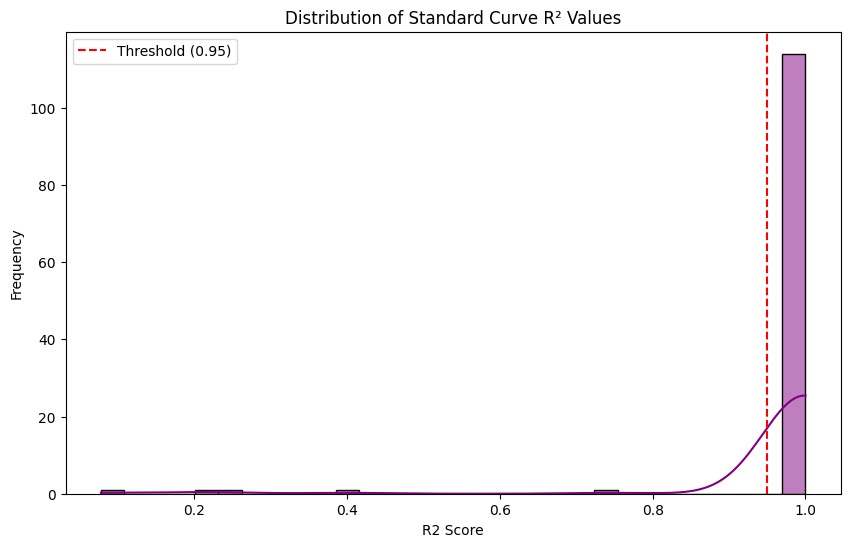

Total Standard Curves evaluated: 119
Average R² Score: 0.9710
Curves failing R² threshold (<0.95): 5

Chips associated with failed curves: ['B72604R8016', 'B72604R8030', 'B52501R8061', 'B72604R8038', 'B72604R8043']
--------------------------------------------------------------------------------
FAILED CURVE DETAILS & PLOTS
--------------------------------------------------------------------------------
Chip ID: B72604R8016 | Curve UUID: csb562a | R²: 0.2006


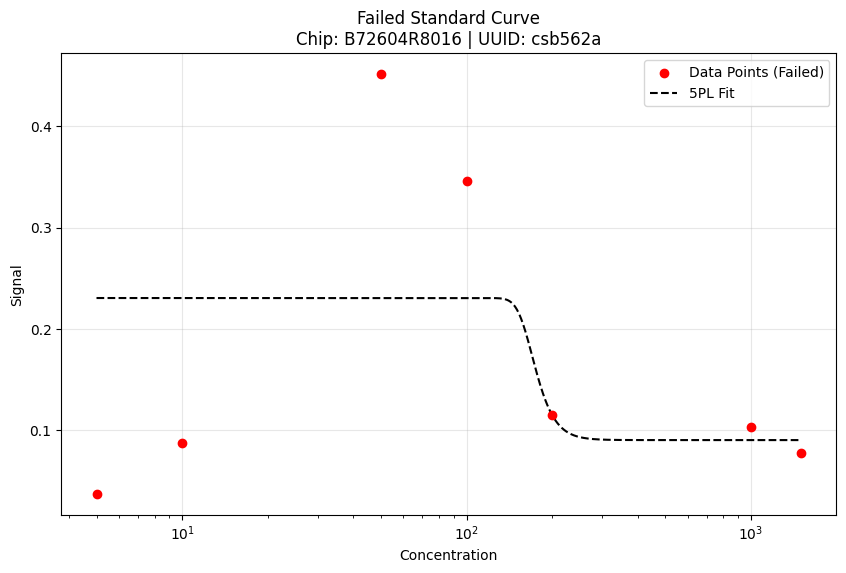

Chip ID: B72604R8030 | Curve UUID: cs36353 | R²: 0.4011


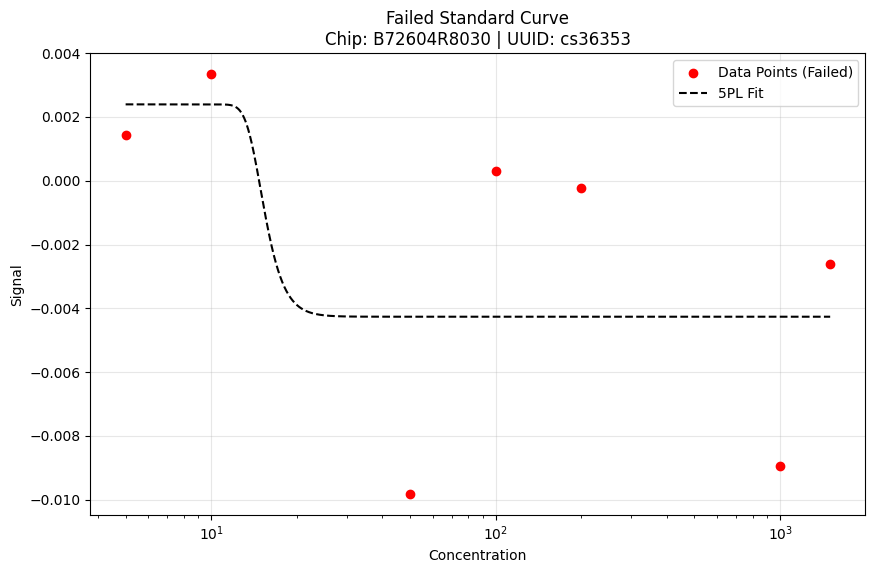

Chip ID: B52501R8061 | Curve UUID: cs84a80 | R²: 0.7446


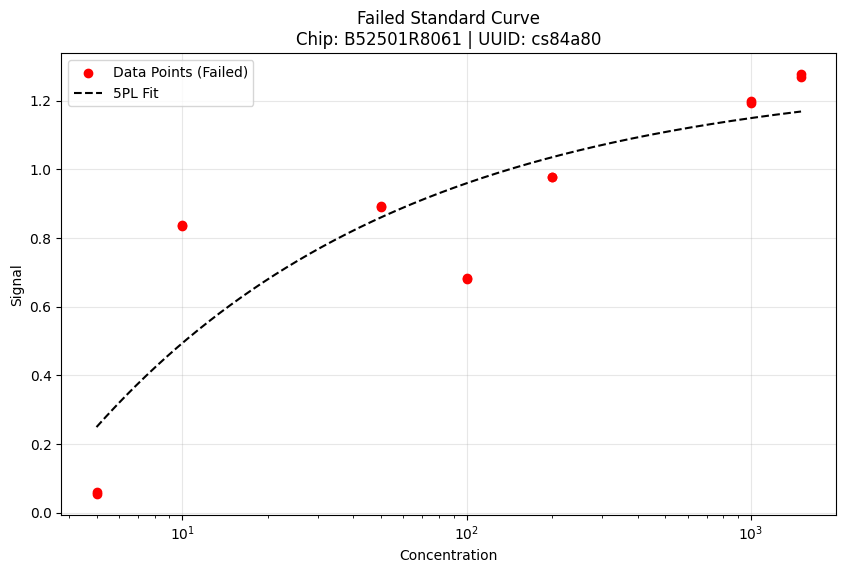

Chip ID: B72604R8038 | Curve UUID: cs2de12 | R²: 0.0775


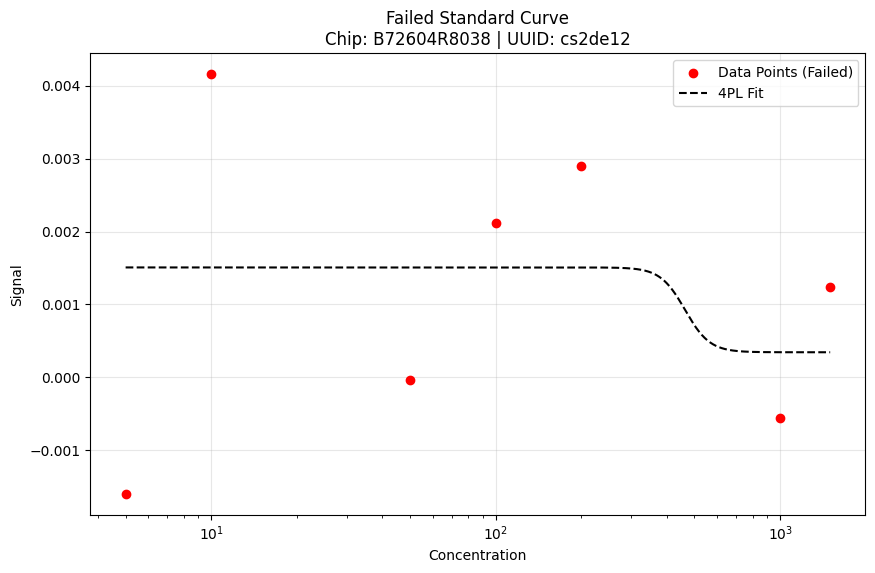

Chip ID: B72604R8043 | Curve UUID: cs419e1 | R²: 0.2325


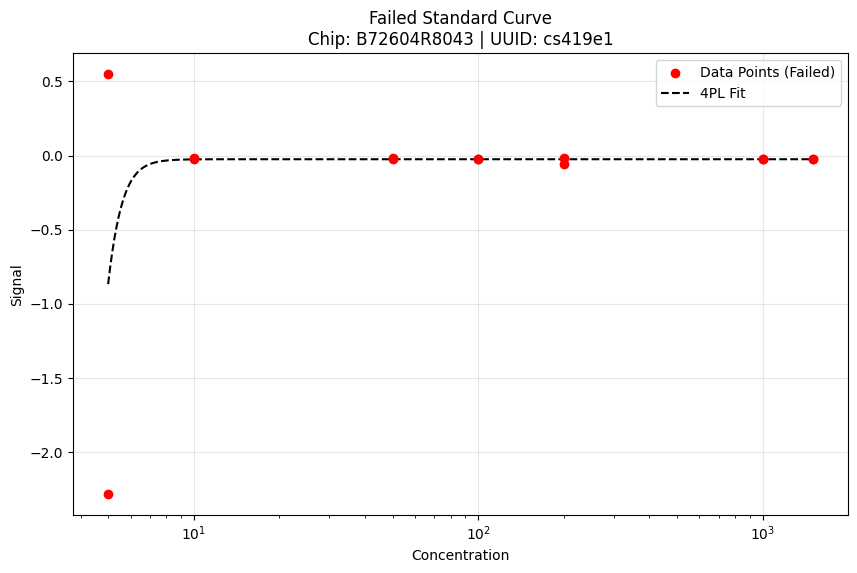

In [37]:
r2_threshold = 0.95

plt.figure(figsize=(10, 6))
sns.histplot(sc_metrics['r2'], bins=30, kde=True, color='purple')
plt.axvline(r2_threshold, color='red', linestyle='--', label=f'Threshold ({r2_threshold})')
plt.title("Distribution of Standard Curve R² Values")
plt.xlabel("R2 Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

failing_curves = sc_metrics[sc_metrics['r2'] < r2_threshold]
failing_chips = failing_curves.index.unique().tolist()

print(f"Total Standard Curves evaluated: {len(sc_metrics)}")
print(f"Average R² Score: {sc_metrics['r2'].mean():.4f}")
print(f"Curves failing R² threshold (<{r2_threshold}): {len(failing_curves)}")

if failing_chips:
    print(f"\nChips associated with failed curves: {failing_chips}")

    print("-" * 80)
    print("FAILED CURVE DETAILS & PLOTS")
    print("-" * 80)
    
    for chip_id, row in failing_curves.iterrows():
        print(f"Chip ID: {chip_id} | Curve UUID: {row['standard_curve_uuid']} | R²: {row['r2']:.4f}")
        
        pts = np.array(row['points'])
        x_data, y_data = pts[:, 0], pts[:, 1]
        
        xfit = np.logspace(np.log10(min(x_data)), np.log10(max(x_data)), 1000)
        
        if row['fit_model'] == '5PL':
            yfit = five_pl(xfit, *row['parameters'])
        else:
            yfit = four_pl(xfit, *row['parameters'])
            
        plt.figure(figsize=(10, 6))
        plt.scatter(x_data, y_data, color='red', label='Data Points (Failed)', zorder=5)
        plt.plot(xfit, yfit, color='black', linestyle='--', label=f"{row['fit_model']} Fit")
        
        plt.xscale('log')
        plt.title(f"Failed Standard Curve\nChip: {chip_id} | UUID: {row['standard_curve_uuid']}")
        plt.xlabel('Concentration')
        plt.ylabel('Signal')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

## $\color{yellow}{\text{Cross-Stage (PEL + Immob) Analysis}}$

### $\color{red}{\text{Anomalies Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [38]:
analyse_cross_stage_split(pel_wide_1, wide_imp_1, "Immediate (Non-Combined)", "Channel 1", pel_anomalies_1, imp_anomalies_1, sc_metrics, title="Cross-Stage PCA: Imm (Non-Comb) Ch1")

analyse_cross_stage_split(pel_wide_2, wide_imp_2, "Immediate (Non-Combined)", "Channel 2", pel_anomalies_2, imp_anomalies_2, sc_metrics, title="Cross-Stage PCA: Imm (Non-Comb) Ch2")

#### $\color{lime}{\text{Immediate (Combined)}}$

In [39]:
analyse_cross_stage_split(pel_wide_1, wide_comb_1, "Immediate (Combined)", "Channel 1", pel_anomalies_1, comb_anomalies_1, sc_metrics, title="Cross-Stage PCA: Immob Immediate Comb (Ch1)")

analyse_cross_stage_split(pel_wide_2, wide_comb_2, "Immediate (Combined)", "Channel 2", pel_anomalies_2, comb_anomalies_2, sc_metrics, title="Cross-Stage PCA: Immob Immediate Comb (Ch2)")

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [40]:
analyse_cross_stage_split(pel_wide_1, wide_avg_imp_1, "5s Average (Non-Combined)", "Channel 1", pel_anomalies_1, avg_imp_anomalies_1, sc_metrics, title="Cross-Stage PCA: Immob 5s Avg Non-Comb (Ch1)")

analyse_cross_stage_split(pel_wide_2, wide_avg_imp_2, "5s Average (Non-Combined)", "Channel 2", pel_anomalies_2, avg_imp_anomalies_2, sc_metrics, title="Cross-Stage PCA: Immob 5s Avg Non-Comb (Ch2)")

#### $\color{lime}{\text{5s Average (Combined)}}$

In [41]:
analyse_cross_stage_split(pel_wide_1, wide_avg_comb_1, "5s Average (Combined)", "Channel 1", pel_anomalies_1, avg_comb_anomalies_1, sc_metrics, title="Cross-Stage PCA: Immob 5s Avg Comb (Ch1)")

analyse_cross_stage_split(pel_wide_2, wide_avg_comb_2, "5s Average (Combined)", "Channel 2", pel_anomalies_2, avg_comb_anomalies_2, sc_metrics, title="Cross-Stage PCA: Immob 5s Avg Comb (Ch2)")

### $\color{red}{\text{Correlations Analysis}}$

#### $\color{lime}{\text{Immediate (Non-Combined)}}$

In [42]:
cross_stage_correlations(pel_wide_1, wide_imp_1, "Immediate (Non-Combined) [Abs]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob Immediate Non-Comb Abs (Ch1)")
cross_stage_correlations(pel_change_wide_1, wide_changes_imp_1, "Immediate (Non-Combined) [Delta]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob Immediate Non-Comb Delta (Ch1)")
cross_stage_correlations(pel_intra_wide_1, wide_intra_imp_1, "Immediate (Non-Combined) [Intra]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob Immediate Non-Comb Intra (Ch1)")

cross_stage_correlations(pel_wide_2, wide_imp_2, "Immediate (Non-Combined) [Abs]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob Immediate Non-Comb Abs (Ch2)")
cross_stage_correlations(pel_change_wide_2, wide_changes_imp_2, "Immediate (Non-Combined) [Delta]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob Immediate Non-Comb Delta (Ch2)")
cross_stage_correlations(pel_intra_wide_2, wide_intra_imp_2, "Immediate (Non-Combined) [Intra]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob Immediate Non-Comb Intra (Ch2)")

#### $\color{lime}{\text{Immediate (Combined)}}$

In [43]:
cross_stage_correlations(pel_wide_1, wide_comb_1, "Immediate (Combined) [Abs]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob Immediate Comb Abs (Ch1)")
cross_stage_correlations(pel_change_wide_1, wide_changes_comb_1, "Immediate (Combined) [Delta]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob Immediate Comb Delta (Ch1)")
cross_stage_correlations(pel_intra_wide_1, wide_intra_comb_1, "Immediate (Combined) [Intra]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob Immediate Comb Intra (Ch1)")

cross_stage_correlations(pel_wide_2, wide_comb_2, "Immediate (Combined) [Abs]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob Immediate Comb Abs (Ch2)")
cross_stage_correlations(pel_change_wide_2, wide_changes_comb_2, "Immediate (Combined) [Delta]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob Immediate Comb Delta (Ch2)")
cross_stage_correlations(pel_intra_wide_2, wide_intra_comb_2, "Immediate (Combined) [Intra]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob Immediate Comb Intra (Ch2)")

#### $\color{lime}{\text{5s Average (Non-Combined)}}$

In [44]:
cross_stage_correlations(pel_wide_1, wide_avg_imp_1, "5s Average (Non-Combined) [Abs]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Non-Comb Abs (Ch1)")
cross_stage_correlations(pel_change_wide_1, wide_changes_avg_imp_1, "5s Average (Non-Combined) [Delta]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Non-Comb Delta (Ch1)")
cross_stage_correlations(pel_intra_wide_1, wide_intra_avg_imp_1, "5s Average (Non-Combined) [Intra]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Non-Comb Intra (Ch1)")

cross_stage_correlations(pel_wide_2, wide_avg_imp_2, "5s Average (Non-Combined) [Abs]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Non-Comb Abs (Ch2)")
cross_stage_correlations(pel_change_wide_2, wide_changes_avg_imp_2, "5s Average (Non-Combined) [Delta]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Non-Comb Delta (Ch2)")
cross_stage_correlations(pel_intra_wide_2, wide_intra_avg_imp_2, "5s Average (Non-Combined) [Intra]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Non-Comb Intra (Ch2)")

#### $\color{lime}{\text{5s Average (Combined)}}$

In [45]:
cross_stage_correlations(pel_wide_1, wide_avg_comb_1, "5s Average (Combined) [Abs]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Comb Abs (Ch1)")
cross_stage_correlations(pel_change_wide_1, wide_changes_avg_comb_1, "5s Average (Combined) [Delta]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Comb Delta (Ch1)")
cross_stage_correlations(pel_intra_wide_1, wide_intra_avg_comb_1, "5s Average (Combined) [Intra]", "Channel 1", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Comb Intra (Ch1)")

cross_stage_correlations(pel_wide_2, wide_avg_comb_2, "5s Average (Combined) [Abs]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Comb Abs (Ch2)")
cross_stage_correlations(pel_change_wide_2, wide_changes_avg_comb_2, "5s Average (Combined) [Delta]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Comb Delta (Ch2)")
cross_stage_correlations(pel_intra_wide_2, wide_intra_avg_comb_2, "5s Average (Combined) [Intra]", "Channel 2", sc_metrics, title="Cross-Stage Corr: Immob 5s Avg Comb Intra (Ch2)")

## $\color{yellow}{\text{Interactive Stage Comparison Dashboards}}$

### $\color{red}{\text{Setup}}$

In [46]:
sc_copy = sc_metrics.copy()
sc_copy.columns = sc_copy.columns.astype(str)

numeric_cols = sc_copy.select_dtypes(include="number").columns.tolist()

if "datetime" in sc_copy.columns:
    sc_copy = sc_copy[["datetime"] + numeric_cols]
else:
    sc_copy = sc_copy[numeric_cols]

sc_first = sc_copy.sort_values("datetime").groupby(sc_copy.index, sort=False).first().drop(columns="datetime")

In [47]:
master_data_catalog = {
    'Absolute': {
        'PEL': {'Channel 1': pel_wide_1, 'Channel 2': pel_wide_2},
        'Immob (Imm, Non-Comb)': {'Channel 1': wide_imp_1, 'Channel 2': wide_imp_2},
        'Immob (Imm, Comb)': {'Channel 1': wide_comb_1, 'Channel 2': wide_comb_2},
        'Immob (5s, Non-Comb)': {'Channel 1': wide_avg_imp_1, 'Channel 2': wide_avg_imp_2},
        'Immob (5s, Comb)': {'Channel 1': wide_avg_comb_1, 'Channel 2': wide_avg_comb_2},
        'Standard Curve': {'Channel 1': sc_first, 'Channel 2': sc_first} 
    },
    
    'Stage Delta': {
        'PEL': {'Channel 1': pel_change_wide_1, 'Channel 2': pel_change_wide_2},
        'Immob (Imm, Non-Comb)': {'Channel 1': wide_changes_imp_1, 'Channel 2': wide_changes_imp_2},
        'Immob (Imm, Comb)': {'Channel 1': wide_changes_comb_1, 'Channel 2': wide_changes_comb_2},
        'Immob (5s, Non-Comb)': {'Channel 1': wide_changes_avg_imp_1, 'Channel 2': wide_changes_avg_imp_2},
        'Immob (5s, Comb)': {'Channel 1': wide_changes_avg_comb_1, 'Channel 2': wide_changes_avg_comb_2},
        'Standard Curve': {'Channel 1': sc_first, 'Channel 2': sc_first}
    },

    'Intra-stage Kinetics': {
        'PEL': {'Channel 1': pel_intra_wide_1, 'Channel 2': pel_intra_wide_2},
        'Immob (Imm, Non-Comb)': {'Channel 1': wide_intra_imp_1, 'Channel 2': wide_intra_imp_2},
        'Immob (Imm, Comb)': {'Channel 1': wide_intra_comb_1, 'Channel 2': wide_intra_comb_2},
        'Immob (5s, Non-Comb)': {'Channel 1': wide_intra_avg_imp_1, 'Channel 2': wide_intra_avg_imp_2},
        'Immob (5s, Comb)': {'Channel 1': wide_intra_avg_comb_1, 'Channel 2': wide_intra_avg_comb_2},
        'Standard Curve': {'Channel 1': sc_first, 'Channel 2': sc_first}
    }
}

### $\color{red}{\text{Display}}$

In [48]:
create_interactive_dashboard(master_data_catalog)

HTML(value="<h3 style='margin-bottom:0px; color:#0000FF;'>Master Chip Comparison Dashboard</h3>")

Output()

# $\color{orange}{\text{Overall Summary}}$

## $\color{yellow}{\text{Setup}}$

In [52]:
section_config = {
    "PEL Absolute (Ch1)": prepare_section(pel_events_norm, 'stage', 'quad_ch1'),
    "PEL Delta (Ch1)": prepare_section(pel_changes, 'stage', 'quad_ch1_change'),
    "PEL Intra-stage Kinetics (Ch1)": (pel_intra_wide_1, outlier_chips_intra_pel_1),

    "PEL Absolute (Ch2)": prepare_section(pel_events_norm, 'stage', 'quad_ch2'),
    "PEL Delta (Ch2)": prepare_section(pel_changes, 'stage', 'quad_ch2_change'),
    "PEL Intra-stage Kinetics (Ch2)": (pel_intra_wide_2, outlier_chips_intra_pel_2),

    "Immob Immediate Abs Non-Comb (Ch1)": prepare_section(imp_norm, 'stage', 'channel1'),
    "Immob Immediate Delta Non-Comb (Ch1)": prepare_section(imp_changes, 'stage', 'channel1_change'),
    "Immob Immediate Intra-stage Non-Comb (Ch1)": (wide_intra_imp_1, outliers_imp_intra_1),

    "Immob Immediate Abs Non-Comb (Ch2)": prepare_section(imp_norm, 'stage', 'channel2'),
    "Immob Immediate Delta Non-Comb (Ch2)": prepare_section(imp_changes, 'stage', 'channel2_change'),
    "Immob Immediate Intra-stage Non-Comb (Ch2)": (wide_intra_imp_2, outliers_imp_intra_2),

    "Immob Immediate Abs Comb (Ch1)": prepare_section(comb_norm, 'stage', 'channel1'),
    "Immob Immediate Delta Comb (Ch1)": prepare_section(comb_changes, 'stage', 'channel1_change'),
    "Immob Immediate Intra-stage Comb (Ch1)": (wide_intra_comb_1, outliers_comb_intra_1),

    "Immob Immediate Abs Comb (Ch2)": prepare_section(comb_norm, 'stage', 'channel2'),
    "Immob Immediate Delta Comb (Ch2)": prepare_section(comb_changes, 'stage', 'channel2_change'),
    "Immob Immediate Intra-stage Comb (Ch2)": (wide_intra_comb_2, outliers_comb_intra_2),

    "Immob 5s Avg Abs Non-Comb (Ch1)": prepare_section(avg_imp_norm, 'stage', 'channel1'),
    "Immob 5s Avg Delta Non-Comb (Ch1)": prepare_section(avg_imp_changes, 'stage', 'channel1_change'),
    "Immob 5s Avg Intra-stage Non-Comb (Ch1)": (wide_intra_avg_imp_1, outliers_avg_imp_intra_1),

    "Immob 5s Avg Abs Non-Comb (Ch2)": prepare_section(avg_imp_norm, 'stage', 'channel2'),
    "Immob 5s Avg Delta Non-Comb (Ch2)": prepare_section(avg_imp_changes, 'stage', 'channel2_change'),
    "Immob 5s Avg Intra-stage Non-Comb (Ch2)": (wide_intra_avg_imp_2, outliers_avg_imp_intra_2),

    "Immob 5s Avg Abs Comb (Ch1)": prepare_section(avg_comb_norm, 'stage', 'channel1'),
    "Immob 5s Avg Delta Comb (Ch1)": prepare_section(avg_comb_changes, 'stage', 'channel1_change'),
    "Immob 5s Avg Intra-stage Comb (Ch1)": (wide_intra_avg_comb_1, outliers_avg_comb_intra_1),

    "Immob 5s Avg Abs Comb (Ch2)": prepare_section(avg_comb_norm, 'stage', 'channel2'),
    "Immob 5s Avg Delta Comb (Ch2)": prepare_section(avg_comb_changes, 'stage', 'channel2_change'),
    "Immob 5s Avg Intra-stage Comb (Ch2)": (wide_intra_avg_comb_2, outliers_avg_comb_intra_2)
}

In [54]:
all_at_risk_chips = set(failing_chips)

for _, outliers in section_config.values():
    all_at_risk_chips.update(outliers)

pel_1 = section_config["PEL Absolute (Ch1)"][0].copy().add_suffix('_PEL_Ch1')
pel_2 = section_config["PEL Absolute (Ch2)"][0].copy().add_suffix('_PEL_Ch2')

pel_intra_1 = section_config["PEL Intra-stage Kinetics (Ch1)"][0].copy().add_suffix('_PEL_Intra_Ch1')
pel_intra_2 = section_config["PEL Intra-stage Kinetics (Ch2)"][0].copy().add_suffix('_PEL_Intra_Ch2')

immob_1 = section_config["Immob Immediate Abs Non-Comb (Ch1)"][0].copy().add_suffix('_Immob_Ch1')
immob_2 = section_config["Immob Immediate Abs Non-Comb (Ch2)"][0].copy().add_suffix('_Immob_Ch2')

immob_intra_1 = section_config["Immob Immediate Intra-stage Non-Comb (Ch1)"][0].copy().add_suffix('_Immob_Intra_Ch1')
immob_intra_2 = section_config["Immob Immediate Intra-stage Non-Comb (Ch2)"][0].copy().add_suffix('_Immob_Intra_Ch2')

master_df = pd.concat([pel_1, pel_2, pel_intra_1, pel_intra_2, immob_1, immob_2, immob_intra_1, immob_intra_2], axis=1, join='inner').dropna()

## $\color{yellow}{\text{Chips That May Fail}}$

back tracking pel and immob failed doesnt give same

also need this analysis to work for both channels together not separate 

In [55]:
generate_at_risk_summary(master_df=master_df, sc_metrics=sc_metrics, sc_raw_df=tables['standard_curves'], all_at_risk_chips=all_at_risk_chips, section_config=section_config, title="At-Risk Chips & Anomaly Drivers")

# $\color{orange}{\text{Standard curve extra data}}$

## $\color{yellow}{\text{Getting files}}$

In [56]:
base_dir = "Standard Curve Files"

files = {}

for folder in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder)

    if os.path.isdir(folder_path):
        files[folder] = {}

        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            if file.endswith(".csv"):
                file_name = os.path.splitext(file)[0]

                df = pd.read_csv(file_path)

                # Check if this is the sensorgram file
                if "sensorgram" in file_name.lower():
                    expected = ['time', "channel1", "channel2"]

                    # If headers are missing or incorrect
                    if list(df.columns[:2]) != expected:
                        df = pd.read_csv(file_path, header=None)
                        df.columns = expected

                files[folder][file_name] = df

## $\color{yellow}{\text{Plot measurement flags}}$

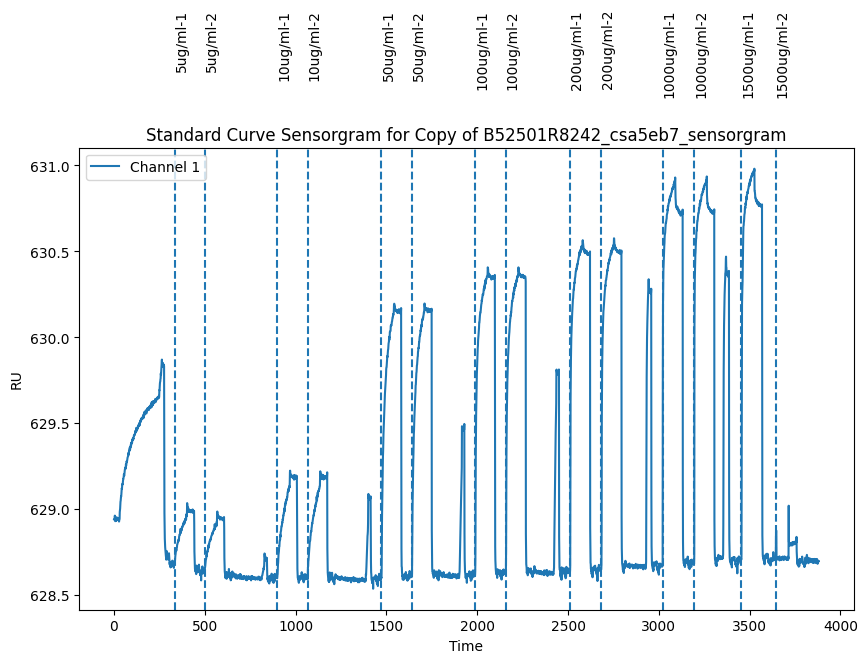

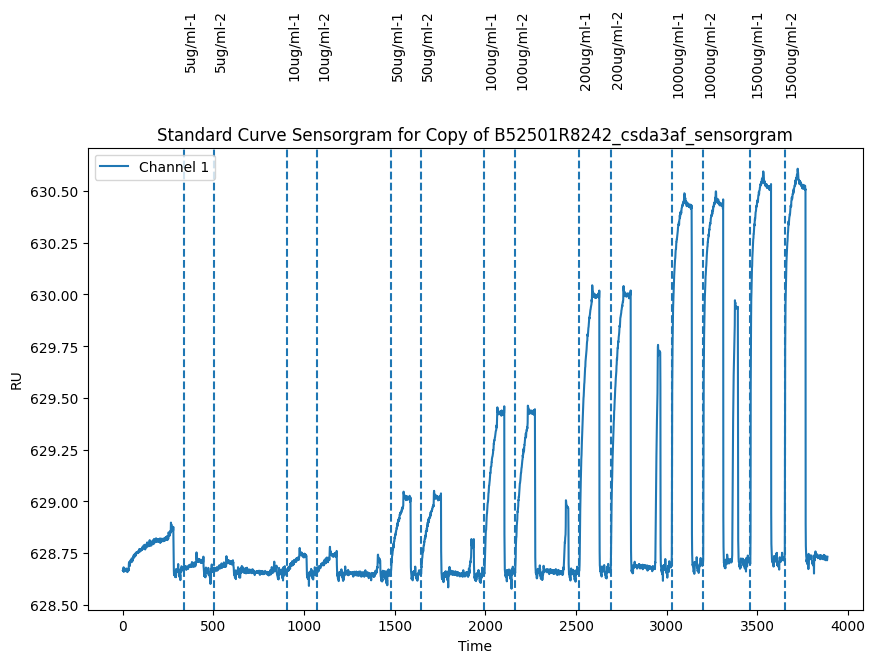

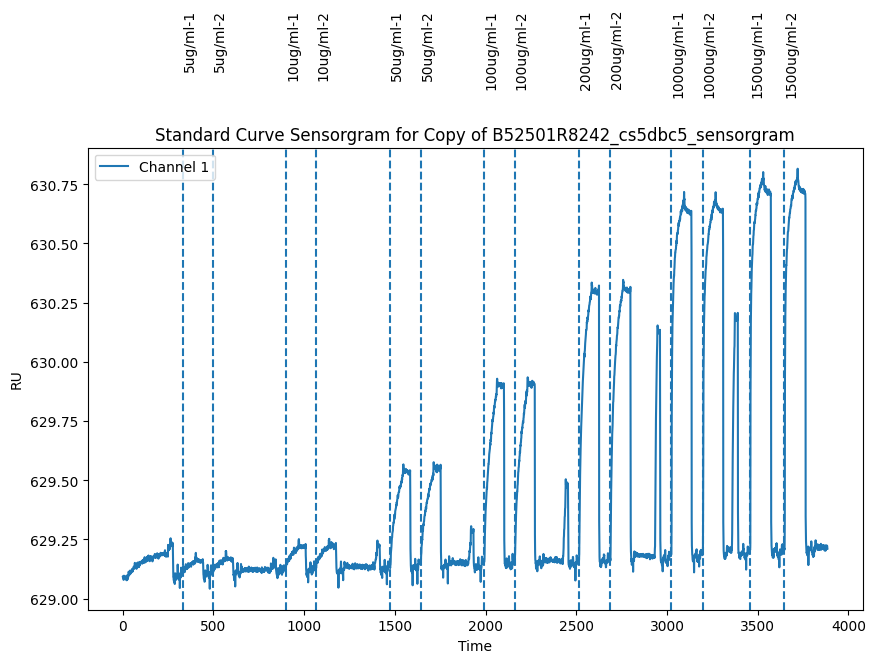

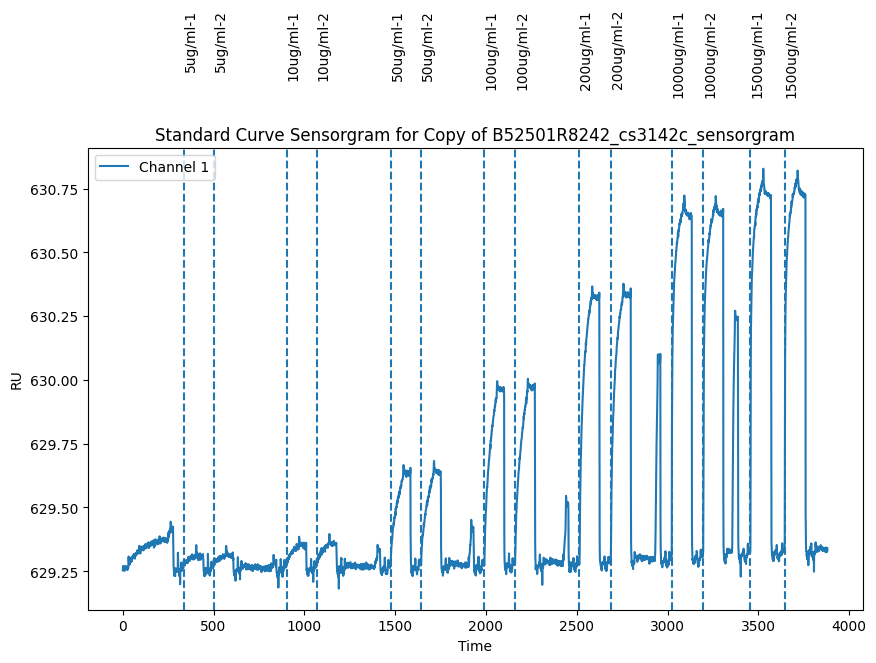

In [57]:
for folder in files.keys():

    previous_file = ''
    for file in files[folder].keys():

        if 'sensorgram' in file:

            file_data = files[folder][file]
            previous_file_data = files[folder][previous_file]

            fig, ax = plt.subplots(figsize=(10, 6))

            plt.plot(file_data['time'], file_data['channel1'], label='Channel 1')

            # Overlay concentration flags from the preceding non-sensorgram file
            for _, flag_row in previous_file_data.iterrows():

                # Plot concentration flag lines
                ax.axvline(x=flag_row['time'], linestyle='--', color='tab:blue')
                ax.text(flag_row['time'], 1.3, flag_row['conc'], rotation=90, transform=ax.get_xaxis_transform(), verticalalignment='top')

            # Set title and labels
            ax.set_title(f'Standard Curve Sensorgram for {file}')
            ax.set_xlabel('Time')
            ax.set_ylabel('RU')
    
            plt.legend()
            plt.show()
            
        previous_file = file

## $\color{yellow}{\text{Baseline flags}}$

### $\color{red}{\text{Calculating}}$

In [58]:
for folder in files.keys():
    
    previous_file = ''

    if 'baseline' in list(files[folder].keys()):
        continue

    for file in list(files[folder].keys()):

        if 'sensorgram' in file:

            file_data = files[folder][file].sort_values('time').reset_index(drop=True)
            previous_file_data = files[folder][previous_file].sort_values('time').reset_index(drop=True)

            # Calculate dynamic row steps based on data frequency
            median_time_step = file_data['time'].diff().median()
            lookahead_rows = max(1, int(5 / median_time_step))
            
            total_block_rows = int(30 / median_time_step) 
            tail_sample_offset = int(5 / median_time_step)
            
            intervals = []
            for i in range(len(previous_file_data) - 1):

                t_start = previous_file_data.iloc[i]['time']
                t_end = previous_file_data.iloc[i+1]['time']
                meas_1 = str(previous_file_data.iloc[i]['conc']).split('-')[0]
                meas_2 = str(previous_file_data.iloc[i+1]['conc']).split('-')[0]
                intervals.append((t_start, t_end, meas_1, meas_2))
                
            last_meas = str(previous_file_data.iloc[-1]['conc']).split('-')[0]
            intervals.append((previous_file_data.iloc[-1]['time'], file_data['time'].max(), last_meas, 'Final'))
                
            saved_file_rows = []
            
            t_absolute_first = file_data['time'].min()
            t_start_init = t_absolute_first
            t_end_init = t_absolute_first + 5.0
            
            init_zone = file_data[(file_data['time'] >= t_start_init) & (file_data['time'] <= t_end_init)]

            if not init_zone.empty:
                saved_file_rows.append({
                    'Window_Start': t_start_init,
                    'Window_End': t_end_init,
                    'information': 'Initial Baseline',
                    'ch1_avg': init_zone['channel1'].mean(),
                    'ch2_avg': init_zone['channel2'].mean(),
                    'ch1_peak': np.nan,
                    'ch2_peak': np.nan,
                    'peak_time': np.nan
                    })
    
            for idx, (t_start, t_end, meas_1, meas_2) in enumerate(intervals):
    
                zone = file_data[(file_data['time'] >= t_start) & (file_data['time'] <= t_end)]
                if zone.empty:
                    continue
                    
                t_mid = t_start + (t_end - t_start) / 2
                sub_zone = zone[zone['time'] >= t_mid] if meas_1 == meas_2 else zone[zone['time'] <= t_mid]
                if sub_zone.empty:
                    sub_zone = zone
    
                drop_size = sub_zone['channel1'] - sub_zone['channel1'].shift(-lookahead_rows)
                if drop_size.dropna().empty:
                    drop_size = sub_zone['channel1'] - sub_zone['channel1'].shift(-1)

                peak_global_idx = drop_size.idxmax()
                exact_row = file_data.loc[peak_global_idx]

                ch1_peak_val = exact_row['channel1']
                ch2_peak_val = exact_row['channel2']
                peak_time_val = exact_row['time']

                max_zone_idx = zone.index.max()
                target_baseline_idx = peak_global_idx + total_block_rows - tail_sample_offset
    
                if target_baseline_idx > max_zone_idx:
                    target_baseline_idx = max(peak_global_idx + lookahead_rows, max_zone_idx - tail_sample_offset)
                
                target_baseline_idx = max(peak_global_idx, min(target_baseline_idx, max_zone_idx))
                baseline_row = file_data.loc[target_baseline_idx]
    
                t_base = baseline_row['time']
                t_start_win = t_base - 2.5
                t_end_win = t_base + 2.5
                
                win_zone = file_data[(file_data['time'] >= t_start_win) & (file_data['time'] <= t_end_win)]
                
                ch1_win_avg = win_zone['channel1'].mean() if not win_zone.empty else baseline_row['channel1']
                ch2_win_avg = win_zone['channel2'].mean() if not win_zone.empty else baseline_row['channel2']
                
                saved_file_rows.append({
                    'Window_Start': t_start_win,
                    'Window_End': t_end_win,
                    'information': f"Baseline Window ({meas_1} / {meas_2})",
                    'ch1_avg': ch1_win_avg,
                    'ch2_avg': ch2_win_avg,
                    'ch1_peak': ch1_peak_val,
                    'ch2_peak': ch2_peak_val,
                    'peak_time': peak_time_val
                })
                
            t_absolute_last = file_data['time'].max()
            t_start_final = t_absolute_last - 5.0
            t_end_final = t_absolute_last
            
            final_zone = file_data[(file_data['time'] >= t_start_final) & (file_data['time'] <= t_end_final)]
    
            saved_file_rows.append({
                'Window_Start': t_start_final,
                'Window_End': t_end_final,
                'information': 'Final Baseline',
                'ch1_avg': final_zone['channel1'].mean(),
                'ch2_avg': final_zone['channel2'].mean(),
                'ch1_peak': np.nan,
                'ch2_peak': np.nan,
                'peak_time': np.nan
            })

            flag_df = pd.DataFrame(saved_file_rows)
            file_name = file.split('_')[1] + '_baseline_flags'
            file_path = 'Standard Curve Files' + '\\' + folder + '\\' + file_name
            
            os.makedirs(os.path.dirname(file_path), exist_ok=True)
            flag_df.to_csv(file_path, index=False)
    
            files[folder][file_name] = flag_df
            
        previous_file = file

### $\color{red}{\text{Plotting}}$

#### $\color{lime}{\text{No Peaks}}$

In [59]:
for folder in files.keys():
    
    previous_file = ''

    for file in list(files[folder].keys()):

        if 'sensorgram' in file:

            file_data = files[folder][file]

            previous_file_data = files[folder][previous_file]

            file_name = file.split('_')[1] + '_baseline_flags'
            baseline_flags = files[folder][file_name]

            baseline_flags['mid_time'] = (baseline_flags['Window_Start'] + baseline_flags['Window_End']) / 2
                    
            fig = go.Figure()
    
            # Plot Channel 1 raw sensor data
            fig.add_trace(go.Scatter(x=file_data['time'], y=file_data['channel1'], mode='lines', name='Channel 1 Raw Data', line=dict(color='#1f77b4', width=1.5)))
    
            # Draw the background experimental injection flags (Vertical Red Dashed Lines)
            for _, flag_row in previous_file_data.iterrows():
                fig.add_vline(
                    x=flag_row['time'], 
                    line_width=1, 
                    line_dash="dash", 
                    line_color="black", 
                    opacity=1
                )
    
                # Place an independent, angled annotation right above the data field
                fig.add_annotation(
                    x=flag_row['time'],
                    y=1.02,
                    yref='paper',
                    text=str(flag_row['conc']),
                    showarrow=False,
                    textangle=-45,
                    xanchor='left',
                    yanchor='bottom',
                    font=dict(size=9, color="#0f0f0f")
                )
    
            # Plot the 5s window center averages as red markers
            fig.add_trace(go.Scatter(
                x=baseline_flags['mid_time'], y=baseline_flags['ch1_avg'],
                mode='markers', name='Saved Baseline (5s Avg)',
                marker=dict(color='red', symbol='circle', size=9),
                hoverinfo='text',
                text=[
                    f"Type: {r['information']}<br>"
                    f"Range: {r['Window_Start']:.1f}s to {r['Window_End']:.1f}s<br>"
                    f"CH1 Avg: {r['ch1_avg']:.2f} RU<br>"
                    f"CH2 Avg: {r['ch2_avg']:.2f} RU" 
                    for _, r in baseline_flags.iterrows()
                ]
            ))
            
            # Draw the shaded green bounding boxes using the saved start/end timestamps
            for _, r in baseline_flags.iterrows():
                fig.add_vrect(
                    x0=r['Window_Start'], x1=r['Window_End'],
                    fillcolor="rgba(44, 160, 44, 0.12)",
                    layer="below", 
                    line_width=1, 
                    line_color="rgba(44, 160, 44, 0.4)",
                    line_dash="dot"
                )
            
            # Horizontal purple target reference line keyed off the initial baseline level
            start_avg_ru = baseline_flags.iloc[0]['ch1_avg']
            fig.add_hline(
                y=start_avg_ru, 
                line_width=1.5, 
                line_dash="dash", 
                line_color="purple",
                annotation_text="Start Average",
                annotation_position="top left"
            )
    
            final_avg_ru = baseline_flags.iloc[-1]['ch1_avg']
            fig.add_hline(
                y=final_avg_ru, 
                line_width=1.5, 
                line_dash="dash", 
                line_color="#e67e22",
                annotation_text="Final Average",
                annotation_position="bottom left"
            )
    
            fig.update_layout(
                title=f'Tail-Sampling Window Method',
                xaxis_title='Time (Seconds)',
                yaxis_title='Response Units (RU)',
                yaxis=dict(range=[file_data['channel1'][0] - 0.5, file_data['channel1'][0] + 2.5]),
                template='plotly_white',
                hovermode='closest'
            )
    
            fig.show()

        previous_file = file

#### $\color{lime}{\text{With Peaks}}$

In [60]:
for folder in files.keys():
    
    previous_file = ''

    for file in list(files[folder].keys()):

        if 'sensorgram' in file:

            file_data = files[folder][file]
            previous_file_data = files[folder][previous_file]

            file_name = file.split('_')[1] + '_baseline_flags'
            baseline_flags = files[folder][file_name]

            baseline_flags['mid_time'] = (baseline_flags['Window_Start'] + baseline_flags['Window_End']) / 2
                    
            fig = go.Figure()
    
            fig.add_trace(go.Scatter(x=file_data['time'], y=file_data['channel1'], mode='lines', name='Channel 1 Raw Data', line=dict(color='#1f77b4', width=1.5)))
    
            for _, flag_row in previous_file_data.iterrows():
                fig.add_vline(x=flag_row['time'], line_width=1, line_dash="dash", line_color="black", opacity=1)
    
                fig.add_annotation(
                    x=flag_row['time'],
                    y=1.02,
                    yref='paper',
                    text=str(flag_row['conc']),
                    showarrow=False,
                    textangle=-45,
                    xanchor='left',
                    yanchor='bottom',
                    font=dict(size=9, color="#0f0f0f")
                )
    
            fig.add_trace(go.Scatter(
                x=baseline_flags['mid_time'], y=baseline_flags['ch1_avg'],
                mode='markers', name='Saved Baseline (5s Avg)',
                marker=dict(color='red', symbol='circle', size=9),
                hoverinfo='text',
                text=[
                    f"Type: {r['information']}<br>"
                    f"Range: {r['Window_Start']:.1f}s to {r['Window_End']:.1f}s<br>"
                    f"CH1 Avg: {r['ch1_avg']:.2f} RU<br>"
                    f"CH2 Avg: {r['ch2_avg']:.2f} RU" 
                    for _, r in baseline_flags.iterrows()
                ]
            ))

            if 'ch1_peak' in baseline_flags.columns and 'peak_time' in baseline_flags.columns:

                valid_peaks = baseline_flags.dropna(subset=['ch1_peak', 'peak_time'])
                
                fig.add_trace(go.Scatter(
                    x=valid_peaks['peak_time'], 
                    y=valid_peaks['ch1_peak'],
                    mode='markers', 
                    name='Pre-Drop Peak',
                    marker=dict(color='orange', symbol='x', size=9, line=dict(color='black', width=1)),
                    hoverinfo='text',
                    text=[
                        f"Peak Value: {r['ch1_peak']:.2f} RU<br>"
                        f"Time: {r['peak_time']:.1f}s" 
                        for _, r in valid_peaks.iterrows()
                    ]
                ))
            
            for _, r in baseline_flags.iterrows():
                fig.add_vrect(
                    x0=r['Window_Start'], x1=r['Window_End'],
                    fillcolor="rgba(44, 160, 44, 0.12)",
                    layer="below", 
                    line_width=1, 
                    line_color="rgba(44, 160, 44, 0.4)",
                    line_dash="dot"
                )
            
            start_avg_ru = baseline_flags.iloc[0]['ch1_avg']
            fig.add_hline(
                y=start_avg_ru, 
                line_width=1.5, 
                line_dash="dash", 
                line_color="purple",
                annotation_text="Start Average",
                annotation_position="top left"
            )
    
            final_avg_ru = baseline_flags.iloc[-1]['ch1_avg']
            fig.add_hline(
                y=final_avg_ru, 
                line_width=1.5, 
                line_dash="dash", 
                line_color="#e67e22",
                annotation_text="Final Average",
                annotation_position="bottom left"
            )
    
            fig.update_layout(
                title=f'Tail-Sampling Window Method with Peaks',
                xaxis_title='Time (Seconds)',
                yaxis_title='Response Units (RU)',
                yaxis=dict(range=[file_data['channel1'][0] - 0.5, file_data['channel1'].max() + 0.5]), # slightly adjusted to ensure peaks fit
                template='plotly_white',
                hovermode='closest'
            )
    
            fig.show()

        previous_file = file

## $\color{yellow}{\text{Extracting Shift}}$


BASELINE SHIFT SUMMARY: csa5eb7_baseline_flags


,Measurement Step,Absolute Peak (RU),Absolute Baseline (RU),Baseline Shift (ΔRU),% Shift of Peak
0,Initial Baseline,NaN,628.941,0.000,NaN
1,Baseline Window (5ug/ml / 5ug/ml),628.988,628.645,-0.296,-626.031
2,Baseline Window (5ug/ml / 10ug/ml),628.952,628.623,-0.318,-2817.408
3,Baseline Window (10ug/ml / 10ug/ml),629.189,628.610,-0.331,-133.350
4,Baseline Window (10ug/ml / 50ug/ml),629.213,628.605,-0.336,-123.788
5,Baseline Window (50ug/ml / 50ug/ml),630.169,628.614,-0.327,-26.590
6,Baseline Window (50ug/ml / 100ug/ml),630.165,628.624,-0.317,-25.852
7,Baseline Window (100ug/ml / 100ug/ml),630.362,628.634,-0.307,-21.627
8,Baseline Window (100ug/ml / 200ug/ml),630.344,628.638,-0.302,-21.564
9,Baseline Window (200ug/ml / 200ug/ml),630.499,628.652,-0.289,-18.536


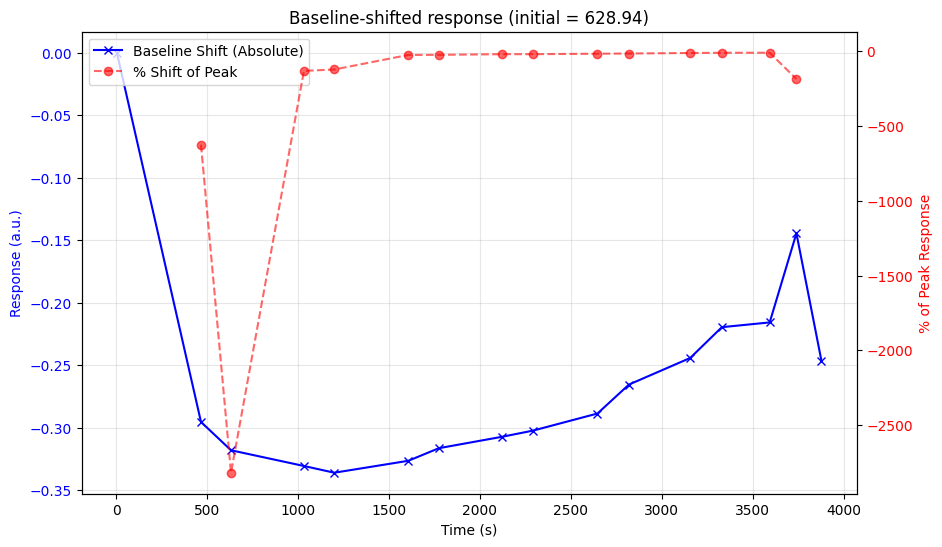


BASELINE SHIFT SUMMARY: csda3af_baseline_flags


,Measurement Step,Absolute Peak (RU),Absolute Baseline (RU),Baseline Shift (ΔRU),% Shift of Peak
0,Initial Baseline,NaN,628.668,0.000,NaN
1,Baseline Window (5ug/ml / 5ug/ml),628.733,628.663,-0.005,-8.280
2,Baseline Window (5ug/ml / 10ug/ml),628.705,628.669,0.000,1.021
3,Baseline Window (10ug/ml / 10ug/ml),628.737,628.652,-0.016,-23.216
4,Baseline Window (10ug/ml / 50ug/ml),628.760,628.655,-0.013,-14.101
5,Baseline Window (50ug/ml / 50ug/ml),629.019,628.660,-0.009,-2.464
6,Baseline Window (50ug/ml / 100ug/ml),629.038,628.652,-0.016,-4.302
7,Baseline Window (100ug/ml / 100ug/ml),629.459,628.656,-0.012,-1.507
8,Baseline Window (100ug/ml / 200ug/ml),629.445,628.664,-0.004,-0.552
9,Baseline Window (200ug/ml / 200ug/ml),630.018,628.676,0.008,0.610


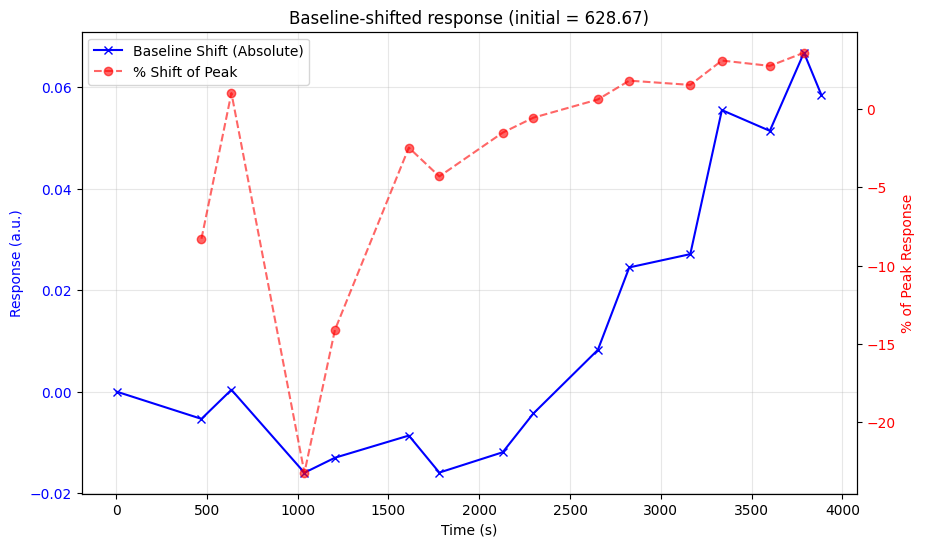


BASELINE SHIFT SUMMARY: cs5dbc5_baseline_flags


,Measurement Step,Absolute Peak (RU),Absolute Baseline (RU),Baseline Shift (ΔRU),% Shift of Peak
0,Initial Baseline,NaN,629.088,0.000,NaN
1,Baseline Window (5ug/ml / 5ug/ml),629.156,629.115,0.027,39.479
2,Baseline Window (5ug/ml / 10ug/ml),629.171,629.126,0.038,45.767
3,Baseline Window (10ug/ml / 10ug/ml),629.231,629.130,0.042,29.230
4,Baseline Window (10ug/ml / 50ug/ml),629.235,629.127,0.040,26.847
5,Baseline Window (50ug/ml / 50ug/ml),629.541,629.135,0.047,10.445
6,Baseline Window (50ug/ml / 100ug/ml),629.565,629.149,0.061,12.766
7,Baseline Window (100ug/ml / 100ug/ml),629.909,629.145,0.057,6.922
8,Baseline Window (100ug/ml / 200ug/ml),629.907,629.156,0.068,8.316
9,Baseline Window (200ug/ml / 200ug/ml),630.322,629.166,0.079,6.370


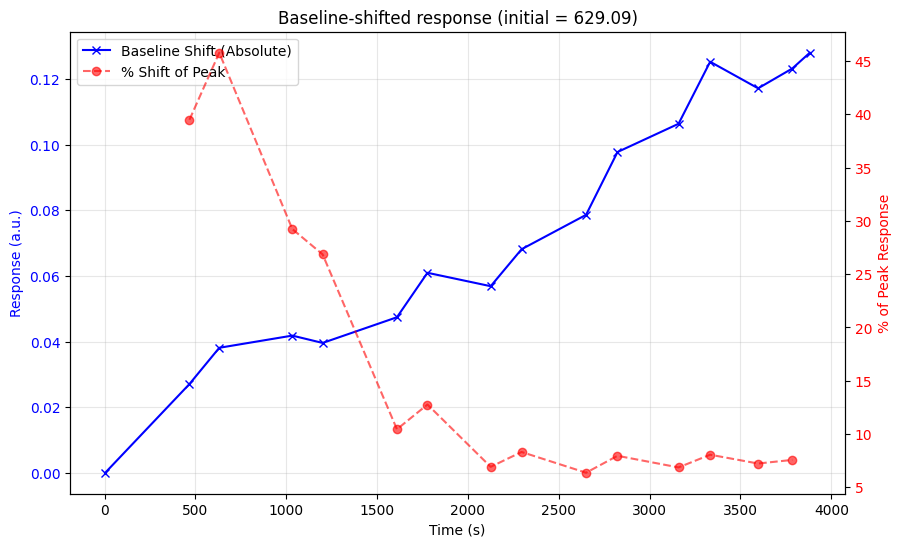


BASELINE SHIFT SUMMARY: cs3142c_baseline_flags


,Measurement Step,Absolute Peak (RU),Absolute Baseline (RU),Baseline Shift (ΔRU),% Shift of Peak
0,Initial Baseline,NaN,629.263,0.000,NaN
1,Baseline Window (5ug/ml / 5ug/ml),629.317,629.264,0.001,1.385
2,Baseline Window (5ug/ml / 10ug/ml),629.323,629.261,-0.002,-3.540
3,Baseline Window (10ug/ml / 10ug/ml),629.361,629.266,0.003,2.617
4,Baseline Window (10ug/ml / 50ug/ml),629.361,629.277,0.013,13.805
5,Baseline Window (50ug/ml / 50ug/ml),629.655,629.277,0.014,3.520
6,Baseline Window (50ug/ml / 100ug/ml),629.635,629.268,0.005,1.336
7,Baseline Window (100ug/ml / 100ug/ml),629.965,629.281,0.018,2.502
8,Baseline Window (100ug/ml / 200ug/ml),629.986,629.288,0.024,3.363
9,Baseline Window (200ug/ml / 200ug/ml),630.342,629.286,0.022,2.060


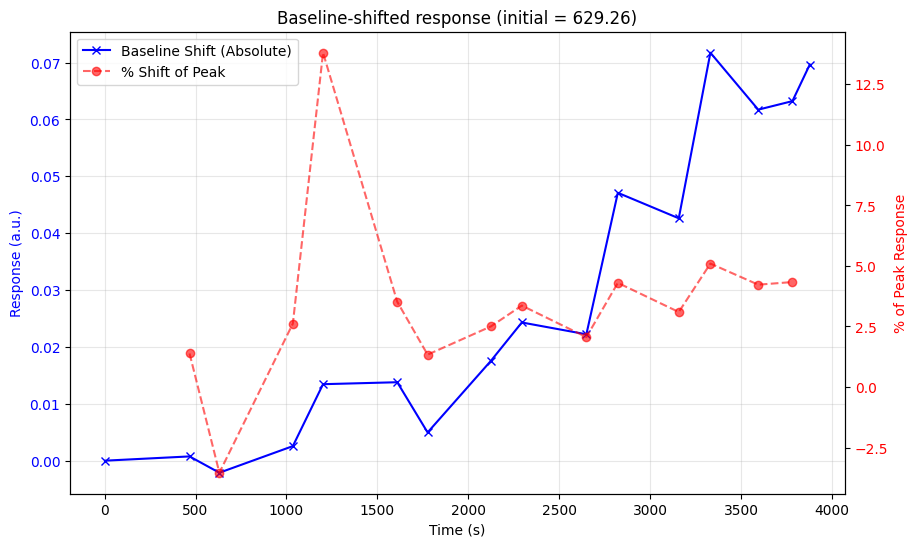

In [61]:
for folder in files.keys():

    for file in files[folder].keys():

        if 'baseline' in file:

            shift_data = files[folder][file]
            
            initial_baseline = shift_data['ch1_avg'].iloc[0]

            baseline_shift = shift_data['ch1_avg'] - initial_baseline
            peak_response = shift_data['ch1_peak'] - initial_baseline
            shift_percentage = (baseline_shift / peak_response) * 100
            
            shift_data['baseline_shift_raw'] = baseline_shift
            shift_data['peak_response_raw'] = peak_response
            shift_data['ch1_shift_pct'] = shift_percentage

            summary_cols = ['information', 'ch1_peak', 'ch1_avg', 'baseline_shift_raw', 'ch1_shift_pct']
            
            # Filter the dataframe to just the columns we want in the table
            summary_table = shift_data[summary_cols].copy()
            
            # Rename columns for presentation
            summary_table.columns = ['Measurement Step', 'Absolute Peak (RU)', 'Absolute Baseline (RU)', 'Baseline Shift (ΔRU)', '% Shift of Peak']
            
            # Round numerical columns for a cleaner display
            summary_table = summary_table.round(3)
            
            print(f"\n{'='*60}")
            print(f"BASELINE SHIFT SUMMARY: {file}")
            print(f"{'='*60}")

            display(summary_table)

            # Create figure
            fig, ax1 = plt.subplots(figsize=(10, 6))

            # Plot absolute baseline shift
            x_times = (shift_data['Window_Start'] + shift_data['Window_End']) / 2
            ax1.plot(x_times, baseline_shift, 'x-', color='b', label='Baseline Shift (Absolute)')
            ax1.set_xlabel('Time (s)')
            ax1.set_ylabel('Response (a.u.)', color='b')
            ax1.tick_params(axis='y', labelcolor='b')
            
            # Plot the percentage
            ax2 = ax1.twinx()
            ax2.plot(x_times, shift_percentage, 'o--', color='r', alpha=0.6, label='% Shift of Peak')
            ax2.set_ylabel('% of Peak Response', color='r')
            ax2.tick_params(axis='y', labelcolor='r')

            plt.title(f'Baseline-shifted response (initial = {initial_baseline:.2f})')
            ax1.grid(True, alpha=0.3)
            
            # Combine legends
            lines_1, labels_1 = ax1.get_legend_handles_labels()
            lines_2, labels_2 = ax2.get_legend_handles_labels()
            ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

            plt.show()

## $\color{yellow}{\text{Setup Functions}}$

In [62]:
def parse_conc_flag(conc_str):
    """
    Parse a concentration flag label (e.g. '5ug/ml-1') into:
    - numeric concentration
    - phase: 1 = association start (injection begins), 2 = dissociation start (injection ends)

    Adjust the regex if your unit label isn't 'ug/ml' (e.g. nM, uM).
    """
    match = re.match(r'([\d.]+)\s*ug/ml-(\d)', str(conc_str))
    if not match:
        return None, None
    
    return float(match.group(1)), int(match.group(2))

In [63]:
def assoc_model(t, Req, kobs, R0, RI):
    """Association with Bulk Shift (RI)"""
    return R0 + RI + Req * (1 - np.exp(-kobs * (t - t[0])))

In [64]:
def dissoc_model(t, R0, kd, Rinf, RI):
    """Dissociation with Bulk Shift (RI) dropping off"""
    
    return Rinf + (R0 - Rinf - RI) * np.exp(-kd * (t - t[0]))

In [65]:
def fit_association(t, y):
    R0_guess = y[0]
    Req_guess = y[-1] - y[0]
    
    try:
        popt, pcov = curve_fit(assoc_model, t, y, p0=[Req_guess, 0.01, R0_guess, 0.0], maxfev=10000)
        return popt
    except RuntimeError:
        return None

In [66]:
def fit_dissociation(t, y):
    R0_guess = y[0]
    Rinf_guess = y[-1]
    
    try:
        popt, pcov = curve_fit(dissoc_model, t, y, p0=[R0_guess, 0.01, Rinf_guess, 0.0], maxfev=10000)
        return popt
    except RuntimeError:
        return None

## $\color{yellow}{\text{Extracting association / dissociation segments}}$

In [67]:
kinetics_results = {}

for folder in files.keys():

    if 'baseline' in folder:
        continue

    previous_file = ''
    for file in list(files[folder].keys()):

        if 'sensorgram' in file:

            sensor = files[folder][file].sort_values('time').reset_index(drop=True)
            flags = files[folder][previous_file].sort_values('time').reset_index(drop=True)

            sensor['response'] = sensor['channel1'] - sensor['channel2']

            parsed = []
            for _, row in flags.iterrows():
                conc_val, phase = parse_conc_flag(row['conc'])
                if conc_val is None:
                    continue
                parsed.append((row['time'], conc_val, phase))

            steps = {}
            for t, c, p in parsed:
                steps.setdefault(c, {})[p] = t

            ordered_concs = sorted(steps.keys(), key=lambda c: steps[c].get(1, np.inf))

            segments = []
            for i, c in enumerate(ordered_concs):
                t_assoc_start = steps[c].get(1)
                t_dissoc_start = steps[c].get(2)
                if t_assoc_start is None or t_dissoc_start is None:
                    continue

                if i + 1 < len(ordered_concs):
                    t_dissoc_end = steps[ordered_concs[i + 1]].get(1, sensor['time'].max())
                else:
                    t_dissoc_end = sensor['time'].max()

                segments.append({
                    'conc': c,
                    't_assoc_start': t_assoc_start,
                    't_assoc_end': t_dissoc_start,
                    't_dissoc_start': t_dissoc_start,
                    't_dissoc_end': t_dissoc_end
                })

            kinetics_results[folder] = {'sensor': sensor, 'segments': segments}

        previous_file = file

## $\color{yellow}{\text{Fitting each concentration step}}$

In [68]:
for folder, data in kinetics_results.items():

    sensor = data['sensor']
    fits = []

    for seg in data['segments']:

        assoc_zone = sensor[(sensor['time'] >= seg['t_assoc_start']) & (sensor['time'] <= seg['t_assoc_end'])]
        dissoc_zone = sensor[(sensor['time'] >= seg['t_dissoc_start']) & (sensor['time'] <= seg['t_dissoc_end'])]

        assoc_fit = fit_association(assoc_zone['time'].values, assoc_zone['response'].values) if len(assoc_zone) > 5 else None
        dissoc_fit = fit_dissociation(dissoc_zone['time'].values, dissoc_zone['response'].values) if len(dissoc_zone) > 5 else None

        fits.append({
            'conc': seg['conc'],
            'assoc_fit': assoc_fit,
            'dissoc_fit': dissoc_fit,
            'assoc_zone': assoc_zone,
            'dissoc_zone': dissoc_zone
        })

    data['fits'] = fits

C:\Users\callu\AppData\Local\Temp\ipykernel_24452\3029923976.py:4: RuntimeWarning:

overflow encountered in exp

C:\Users\callu\AppData\Local\Temp\ipykernel_24452\2795502749.py:3: RuntimeWarning:

overflow encountered in exp



## $\color{yellow}{\text{Global ka, kd, KD (kobs vs concentration)}}$

In [69]:
for folder, data in kinetics_results.items():

    concs = [f['conc'] for f in data['fits'] if f['assoc_fit'] is not None]
    kobs_vals = [f['assoc_fit'][1] for f in data['fits'] if f['assoc_fit'] is not None]

    if len(concs) < 2:
        print(f"{folder}: not enough successful association fits for a global ka/kd fit")
        continue

    slope, intercept, r_value, _, _ = linregress(concs, kobs_vals)
    ka = slope
    kd_from_intercept = intercept
    KD = kd_from_intercept / ka if ka != 0 else np.nan

    data['ka'] = ka
    data['kd'] = kd_from_intercept
    data['KD'] = KD
    data['kobs_r2'] = r_value ** 2

    dissoc_kds = [f['dissoc_fit'][1] for f in data['fits'] if f['dissoc_fit'] is not None]
    if dissoc_kds:
        data['kd_dissoc_mean'] = np.mean(dissoc_kds)

    print(f"{folder}: ka = {ka:.3e} (ug/ml*s)^-1, kd(intercept) = {kd_from_intercept:.3e} s^-1, kd(dissoc mean) = {data.get('kd_dissoc_mean', np.nan):.3e} s^-1, KD = {KD:.3e} ug/ml, kobs fit R2 = {r_value**2:.4f}")

2026-04-13: ka = 5.077e-04 (ug/ml*s)^-1, kd(intercept) = 1.811e-02 s^-1, kd(dissoc mean) = 1.823e-01 s^-1, KD = 3.568e+01 ug/ml, kobs fit R2 = 0.9757
2026-04-15: ka = 2.854e-04 (ug/ml*s)^-1, kd(intercept) = 4.840e-02 s^-1, kd(dissoc mean) = 9.716e-02 s^-1, KD = 1.696e+02 ug/ml, kobs fit R2 = 0.4719
2026-04-16: ka = 1.130e-04 (ug/ml*s)^-1, kd(intercept) = 8.713e-02 s^-1, kd(dissoc mean) = 1.373e-01 s^-1, KD = 7.713e+02 ug/ml, kobs fit R2 = 0.1029


## $\color{yellow}{\text{Per-concentration kinetic parameters}}$

In [70]:
for folder, data in kinetics_results.items():
    if 'fits' not in data:
        continue
        
    per_conc_rows = []
    
    for f in data['fits']:
        conc = f['conc']
        warning = ""
        
        if f['assoc_fit'] is not None:
            Req, kobs, R0, RI = f['assoc_fit']
        else:
            Req, kobs, R0 = np.nan, np.nan, np.nan
            warning += "Assoc fit failed; "
            
        if f['dissoc_fit'] is not None:
            R0d, kd, Rinf, RI = f['dissoc_fit']
        else:
            R0d, kd, Rinf = np.nan, np.nan, np.nan
            warning += "Dissoc fit failed; "
            
        if not np.isnan(kobs) and not np.isnan(kd) and conc > 0:
            ka_indiv = (kobs - kd) / conc
            KD_indiv = kd / ka_indiv
            
            if kd >= kobs:
                warning += "kd >= kobs (Negative k_a); "
        else:
            ka_indiv = np.nan
            KD_indiv = np.nan
            
        per_conc_rows.append({
            'Concentration (ug/ml)': conc,
            'k_obs (s^-1)': kobs,
            'k_d (s^-1) [from dissoc]': kd,
            'k_a (ug/ml*s)^-1 [calculated]': ka_indiv,
            'K_D (ug/ml)': KD_indiv,
            'R_eq (RU)': Req,
            'Fit Warning': warning.strip('; ')
        })
        
    if per_conc_rows:
        per_conc_summary = pd.DataFrame(per_conc_rows)
        per_conc_summary = per_conc_summary.sort_values(by=['Concentration (ug/ml)']).reset_index(drop=True)
        
        display(f"Chip / File: {folder}")
        display(per_conc_summary)

'Chip / File: 2026-04-13'

,Concentration (ug/ml),k_obs (s^-1),k_d (s^-1) [from dissoc],k_a (ug/ml*s)^-1 [calculated],K_D (ug/ml),R_eq (RU),Fit Warning
0,5.0,6.351680e-07,0.004014,-0.000803,-5.000791,-302.292532,kd >= kobs (Negative k_a)
1,10.0,4.498150e-07,0.005054,-0.000505,-10.000890,-772.409730,kd >= kobs (Negative k_a)
2,50.0,-2.678279e-02,0.382220,-0.008180,-46.725840,0.004312,kd >= kobs (Negative k_a)
3,100.0,1.327603e-01,0.003555,0.001292,2.751216,0.457218,
4,200.0,1.709211e-01,0.003752,0.000836,4.488356,0.848780,
5,1000.0,5.482516e-01,0.000007,0.000548,0.012404,1.195885,
6,1500.0,7.560694e-01,0.877530,-0.000081,-10837.177180,1.155912,kd >= kobs (Negative k_a)


'Chip / File: 2026-04-15'

,Concentration (ug/ml),k_obs (s^-1),k_d (s^-1) [from dissoc],k_a (ug/ml*s)^-1 [calculated],K_D (ug/ml),R_eq (RU),Fit Warning
0,5.0,6.899373e-07,0.006587,-0.001317,-5.000524,-313.921787,kd >= kobs (Negative k_a)
1,10.0,5.714086e-07,0.007302,-0.000730,-10.000783,-731.856036,kd >= kobs (Negative k_a)
2,50.0,1.349718e-01,0.003396,0.002632,1.290628,0.240174,
3,100.0,1.404859e-01,0.003762,0.001367,2.751387,0.464685,
4,200.0,2.075187e-01,0.004291,0.001016,4.222735,0.730255,
5,1000.0,-1.745142e-02,0.000008,-0.000017,-0.437791,0.096502,kd >= kobs (Negative k_a)
6,1500.0,6.908880e-01,0.654765,0.000024,27189.330685,1.008828,


'Chip / File: 2026-04-16'

,Concentration (ug/ml),k_obs (s^-1),k_d (s^-1) [from dissoc],k_a (ug/ml*s)^-1 [calculated],K_D (ug/ml),R_eq (RU),Fit Warning
0,5.0,7.557411e-07,0.006253,-1.250533e-03,-5.000604,-368.309003,kd >= kobs (Negative k_a)
1,10.0,7.889175e-07,0.006966,-6.965410e-04,-10.001133,-550.627533,kd >= kobs (Negative k_a)
2,50.0,5.631295e-07,0.482259,-9.645159e-03,-50.000058,-2718.283586,kd >= kobs (Negative k_a)
3,100.0,1.474967e-01,0.003884,1.436127e-03,2.704512,0.402550,
4,200.0,2.226373e-01,0.461837,-1.195997e-03,-386.152040,0.645100,kd >= kobs (Negative k_a)
5,1000.0,5.634495e-01,0.000011,5.634389e-04,0.018750,0.907850,
6,1500.0,5.027878e-07,0.000010,-6.424476e-09,-1578.261296,-18321.933593,kd >= kobs (Negative k_a)


## $\color{yellow}{\text{Kinetics summary table}}$

In [71]:
summary_rows = []
for folder, data in kinetics_results.items():
    if 'ka' not in data:
        continue
    
    summary_rows.append({
        'Chip': folder,
        'ka (ug/ml*s)^-1': data['ka'],
        'kd_intercept (s^-1)': data['kd'],
        'kd_dissoc_mean (s^-1)': data.get('kd_dissoc_mean', np.nan),
        'KD (ug/ml)': data['KD'],
        'kobs_fit_R2': data['kobs_r2']
    })

kinetics_summary = pd.DataFrame(summary_rows)
display(kinetics_summary)

,Chip,ka (ug/ml*s)^-1,kd_intercept (s^-1),kd_dissoc_mean (s^-1),KD (ug/ml),kobs_fit_R2
0,2026-04-13,0.000508,0.018115,0.182305,35.683479,0.975698
1,2026-04-15,0.000285,0.048398,0.097159,169.587169,0.471917
2,2026-04-16,0.000113,0.087133,0.137317,771.310697,0.102854


## $\color{yellow}{\text{Plotting kinetic curves}}$

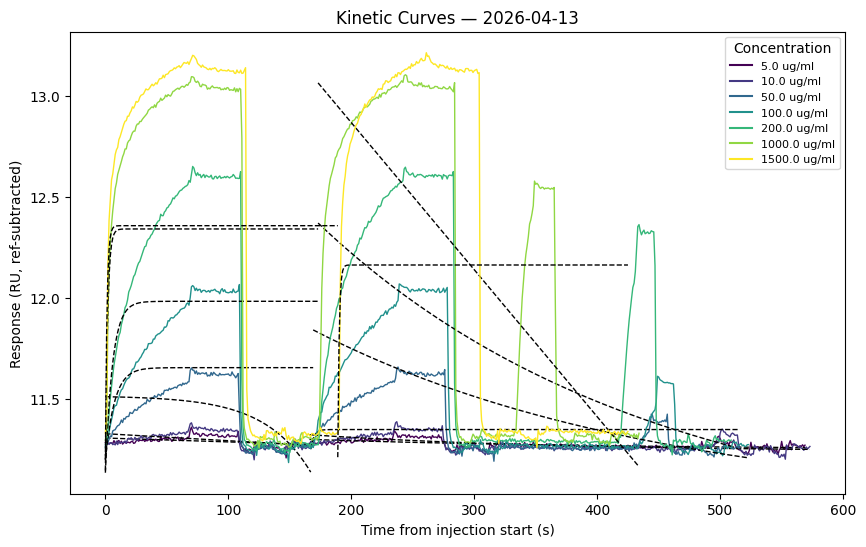

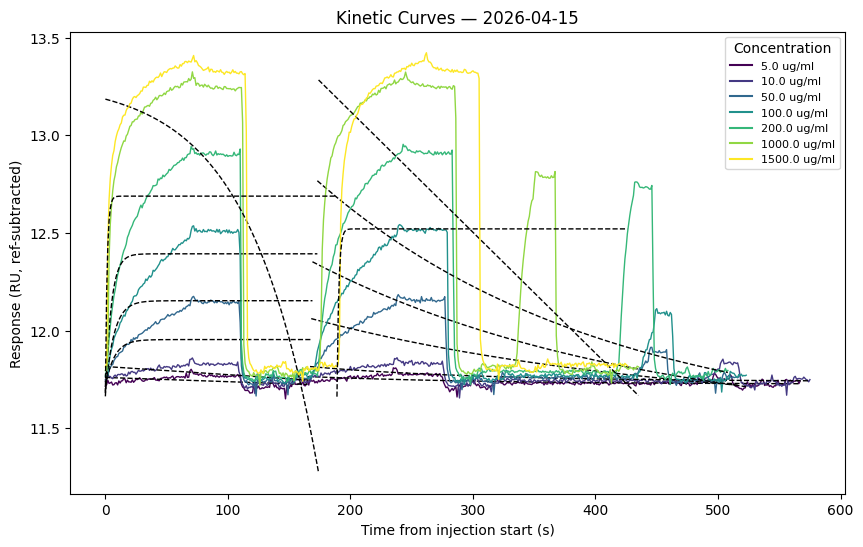

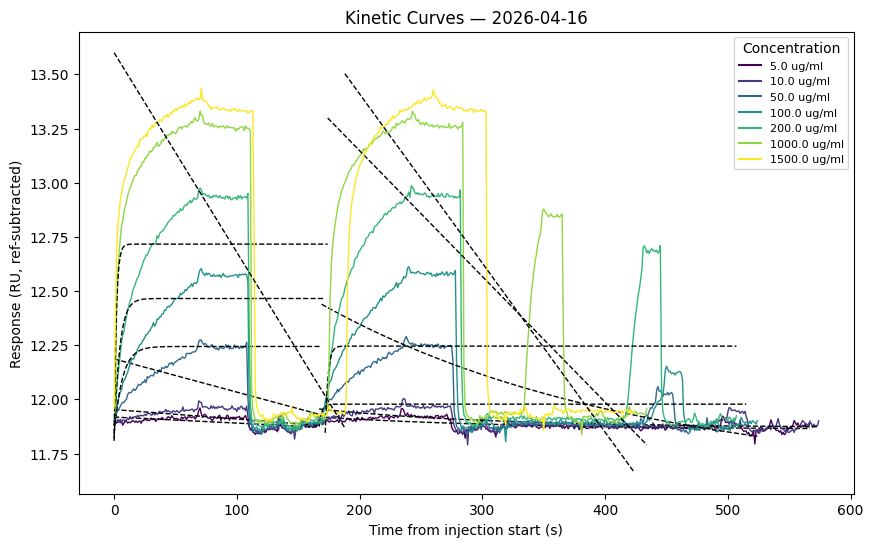

In [72]:
for folder, data in kinetics_results.items():

    if 'fits' not in data:
        continue

    fig, ax = plt.subplots(figsize=(10, 6))
    cmap = plt.cm.viridis
    n = len(data['fits'])

    for i, f in enumerate(data['fits']):
        colour = cmap(i / max(n - 1, 1))

        assoc_zone = f['assoc_zone']
        dissoc_zone = f['dissoc_zone']

        if assoc_zone.empty:
            continue

        t0 = assoc_zone['time'].iloc[0]
        
        ax.plot(assoc_zone['time'] - t0, assoc_zone['response'], color=colour, lw=1)
        if not dissoc_zone.empty:
            ax.plot(dissoc_zone['time'] - t0, dissoc_zone['response'], color=colour, lw=1)

        # Fitted curves overlaid in black
        if f['assoc_fit'] is not None:
            Req, kobs, R0, RI_a = f['assoc_fit']
            t_fit = assoc_zone['time'].values
            ax.plot(t_fit - t0, assoc_model(t_fit, Req, kobs, R0, RI_a), '--', color='black', lw=1)

        if f['dissoc_fit'] is not None:
            R0d, kd, Rinf, RI_d = f['dissoc_fit']
            t_fit_d = dissoc_zone['time'].values
            ax.plot(t_fit_d - t0, dissoc_model(t_fit_d, R0d, kd, Rinf, RI_d), '--', color='black', lw=1)

        ax.plot([], [], color=colour, label=f"{f['conc']} ug/ml")

    ax.set_xlabel('Time from injection start (s)')
    ax.set_ylabel('Response (RU, ref-subtracted)')
    ax.set_title(f'Kinetic Curves — {folder}')
    ax.legend(title='Concentration', fontsize=8)
    plt.show()

## $\color{yellow}{\text{kobs vs concentration}}$

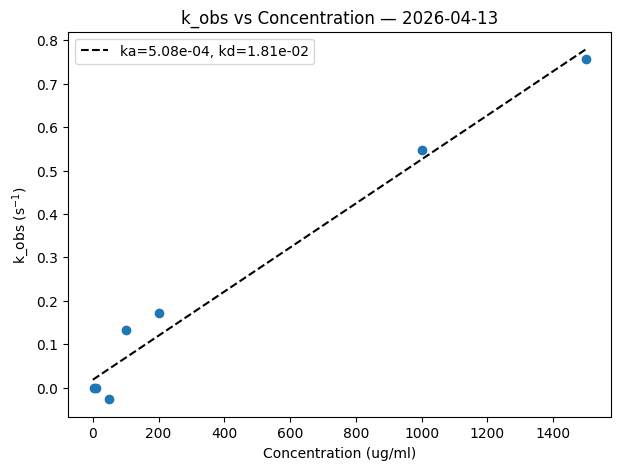

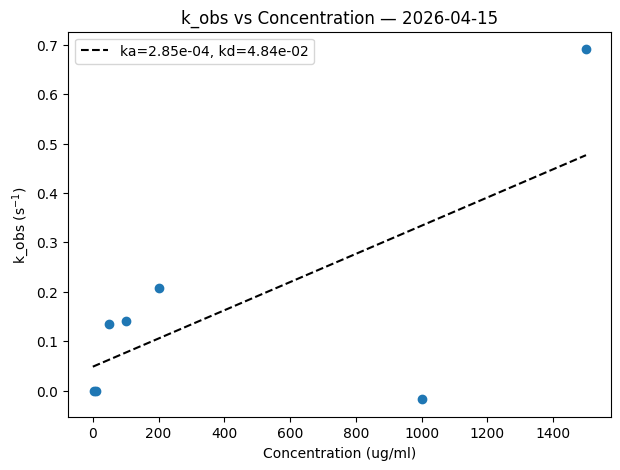

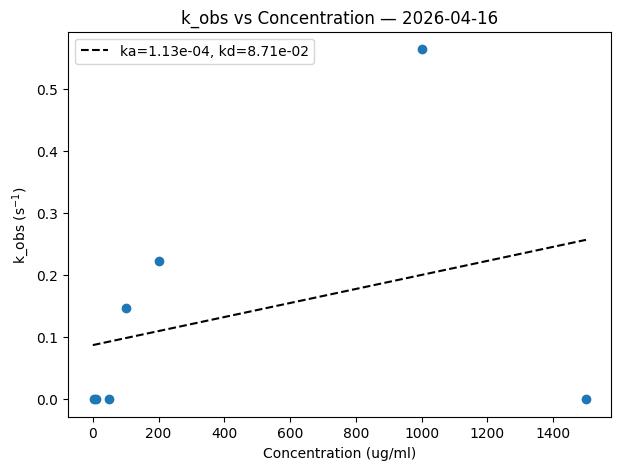

In [73]:
for folder, data in kinetics_results.items():

    if 'ka' not in data:
        continue

    concs = [f['conc'] for f in data['fits'] if f['assoc_fit'] is not None]
    kobs_vals = [f['assoc_fit'][1] for f in data['fits'] if f['assoc_fit'] is not None]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(concs, kobs_vals, color='tab:blue')

    x_fit = np.linspace(0, max(concs), 50)
    y_fit = data['ka'] * x_fit + data['kd']
    ax.plot(x_fit, y_fit, '--', color='black', label=f"ka={data['ka']:.2e}, kd={data['kd']:.2e}")

    ax.set_xlabel('Concentration (ug/ml)')
    ax.set_ylabel('k_obs (s$^{-1}$)')
    ax.set_title(f'k_obs vs Concentration — {folder}')
    ax.legend()
    plt.show()

## $\color{yellow}{\text{Binding curves (aligned, baseline-zeroed overlay)}}$

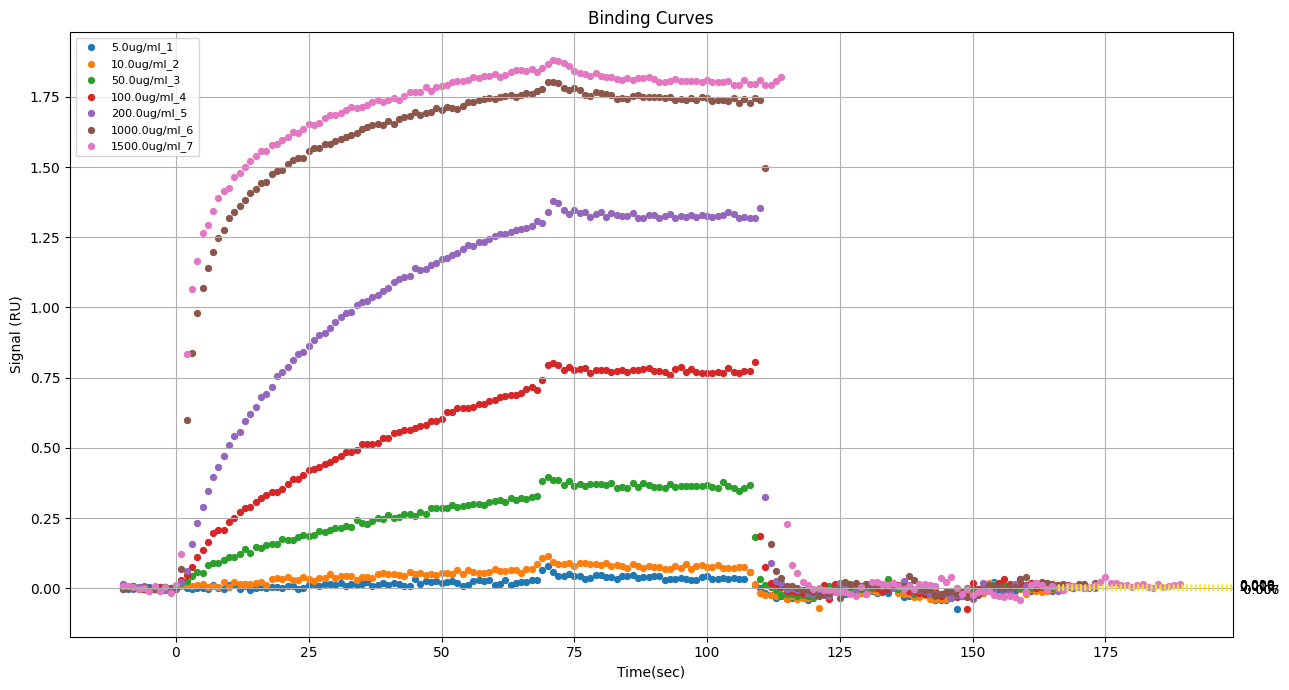

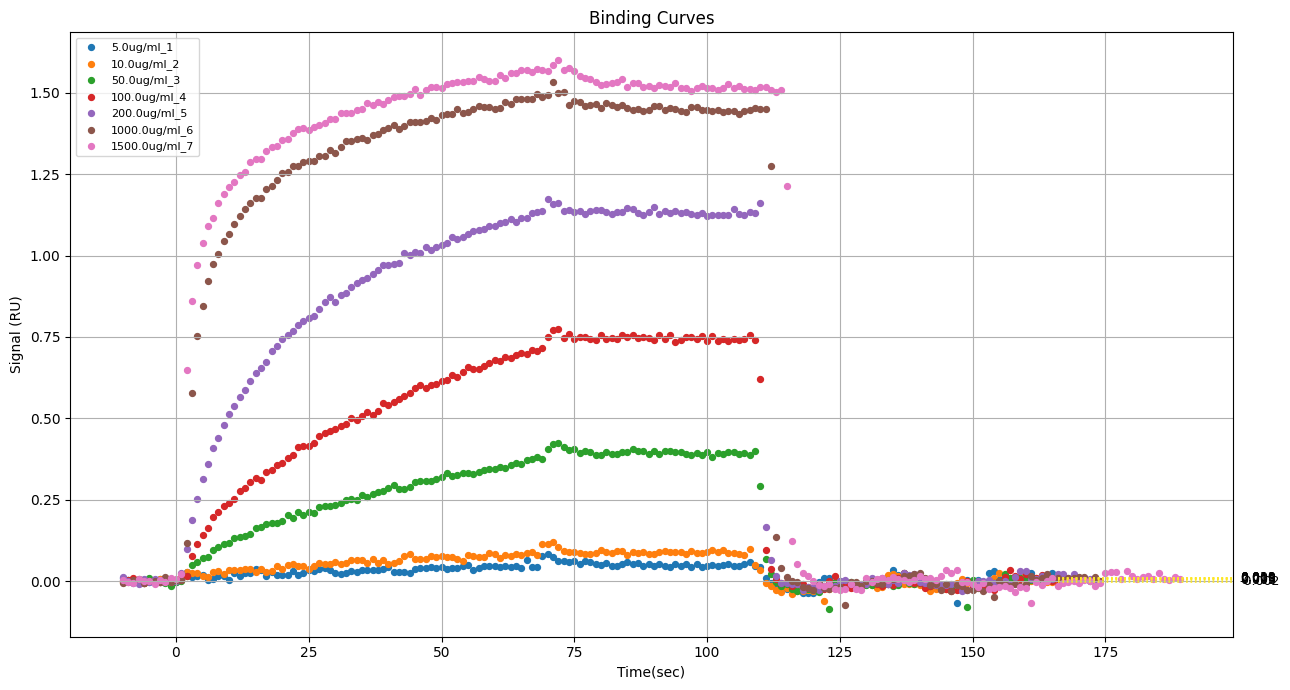

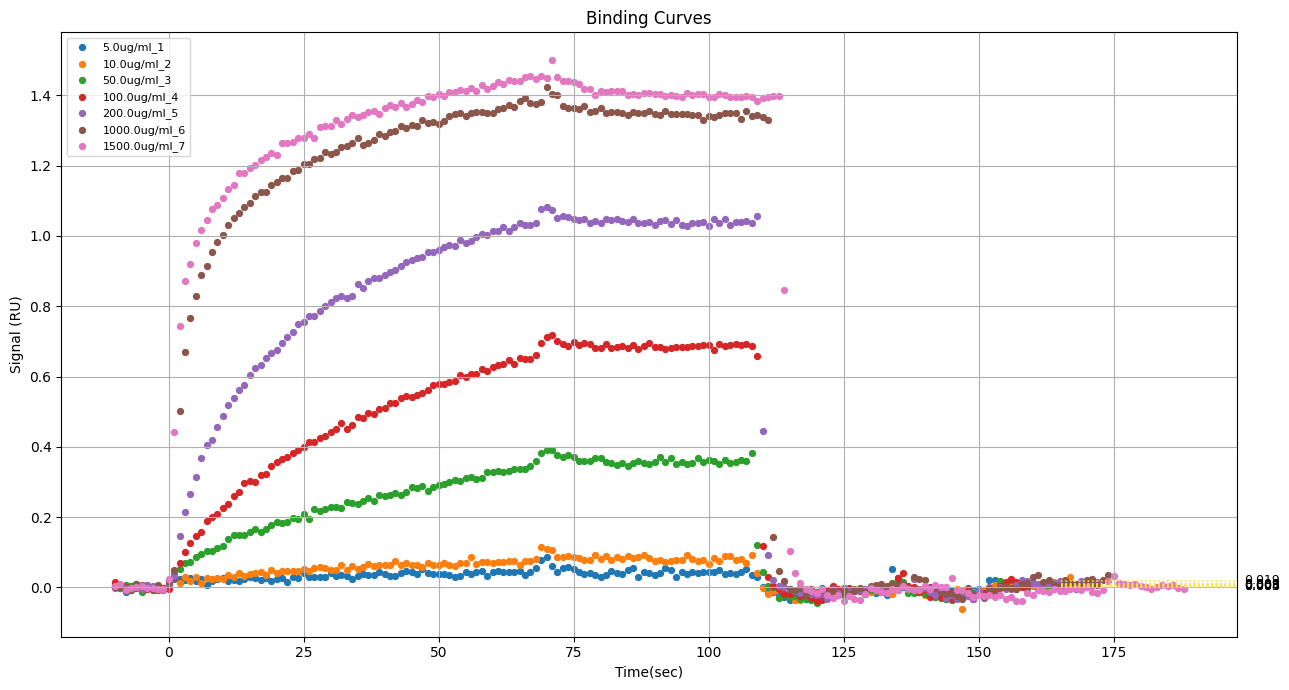

In [74]:
pre_baseline_seconds = 10
tail_avg_seconds = 5

for folder, data in kinetics_results.items():

    if 'fits' not in data:
        continue

    sensor = data['sensor']
    fig, ax = plt.subplots(figsize=(13, 7))

    curve_id = 0
    for f in data['fits']:

        assoc_zone = f['assoc_zone']
        if assoc_zone.empty:
            continue

        t0 = assoc_zone['time'].iloc[0]

        # Extend the window backwards to capture the pre-injection baseline
        window = sensor[(sensor['time'] >= t0 - pre_baseline_seconds) & (sensor['time'] <= assoc_zone['time'].iloc[-1])]

        # Baseline-zero using the pre-injection portion
        pre_zone = window[window['time'] < t0]
        baseline = pre_zone['response'].mean() if not pre_zone.empty else window['response'].iloc[0]

        t_plot = window['time'] - t0
        y_plot = window['response'] - baseline

        label = f"{f['conc']}ug/ml_{curve_id + 1}"

        ax.scatter(t_plot, y_plot, s=18, label=label)

        # Plateau reference line + value label at the right edge
        tail_zone = y_plot[t_plot >= t_plot.max() - tail_avg_seconds]
        plateau_val = tail_zone.mean()

        ax.axhline(y=plateau_val, xmin=0.85, xmax=1.0, linestyle=':', color=colour, linewidth=1.2)
        ax.annotate(f"{plateau_val:.3f}", xy=(1.0, plateau_val), xycoords=('axes fraction', 'data'), xytext=(5, 0), textcoords='offset points', va='center', ha='left', fontsize=9)

        curve_id += 1

    ax.set_xlabel('Time(sec)')
    ax.set_ylabel('Signal (RU)')
    ax.set_title('Binding Curves')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

# $\color{cyan}{\text{Run Check}}$

In [75]:
print('run completed')

run completed


## $\color{yellow}{\text{Seperate}}$

In [76]:
total_ch1_less = 0
total_ch2_less = 0
total_equal = 0

for file_name, file_data in bucket_data['Sensorgram'].items():

    if file_data['quad_ch1'].iloc[0] < file_data['quad_ch2'].iloc[0]:
        total_ch1_less += 1
    elif file_data['quad_ch1'].iloc[0] > file_data['quad_ch2'].iloc[0]:
        total_ch2_less += 1
    else:
        total_equal += 1

print('Ch1 < Ch2: ', total_ch1_less)
print('Ch1 > Ch2: ', total_ch2_less)
print('Ch1 = Ch2: ', total_equal)

Ch1 < Ch2:  164
Ch1 > Ch2:  9
Ch1 = Ch2:  4


In [77]:
total_ch1_less = 0
total_ch2_less = 0
total_equal = 0

for file_name, file_data in bucket_data['RefPoly4'].items():

    if file_data['channel1'].iloc[0] < file_data['channel2'].iloc[0]:
        total_ch1_less += 1
    elif file_data['channel1'].iloc[0] > file_data['channel2'].iloc[0]:
        total_ch2_less += 1
    else:
        total_equal += 1

print('Ch1 < Ch2: ', total_ch1_less)
print('Ch1 > Ch2: ', total_ch2_less)
print('Ch1 = Ch2: ', total_equal)

Ch1 < Ch2:  14
Ch1 > Ch2:  12
Ch1 = Ch2:  0


## $\color{yellow}{\text{Overall}}$

In [78]:
total_less_more = 0
total_more_less = 0
total_less = 0
total_more = 0

pel_ch1_less = 0
pel_ch2_less = 0
pel_equal = 0

immob_ch1_less = 0
immob_ch2_less = 0
immob_equal = 0

total_not_matched = 0
total_matched = 0

crossovers_explained_by_chemistry = 0
crossovers_unexplained_true_swaps = 0

ch1_chemistry_chips = []
ch1_unexplained_chips = []
ch1_same_chips = []

for index, pel_row in tables['pel_upload'].iterrows():

    chip_id = pel_row['chip_id']
    flags_id = pel_row['flags_id']
    sensorgram_file = pel_row['sensorgram']

    if sensorgram_file not in bucket_data['Sensorgram'].keys():
        total_not_matched += 1
        continue
        
    file_data = bucket_data['Sensorgram'][sensorgram_file]

    refpoly4_match = tables['immob'][tables['immob']['chip_id'] == chip_id]

    if refpoly4_match.empty:
        total_not_matched += 1
        continue

    immob_row = refpoly4_match.iloc[0]
    immob_flags_file = immob_row['amfFlags']
    
    immob_flags = bucket_data['AMF_FLAGS'].get(immob_flags_file, pd.DataFrame())

    has_prg = False

    if not immob_flags.empty and 'information' in immob_flags.columns:

        has_prg = any('prg' in str(row.information).lower() for row in immob_flags.itertuples())
        
    if not has_prg:
        total_not_matched += 1
        continue

    pel_flags = tables['flags'][tables['flags']['flags_id'] == flags_id]

    if pel_flags.empty or immob_flags.empty:
        total_not_matched += 1
        continue

    total_matched += 1

    refpoly4_file = immob_row['refPoly4']
    immob_data = bucket_data['RefPoly4'][refpoly4_file]

    pel_start_time = pel_flags['Initial']
    pel_final_time = pel_flags['Final']
    immob_initial_time = immob_flags[immob_flags['information'].str.contains('initial', case=False, na=False)]['time'].iloc[0]

    pel_start_1 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch1'])
    pel_start_2 = np.interp(pel_start_time, file_data['t'], file_data['quad_ch2'])
    
    pel_end_1 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch1'])
    pel_end_2 = np.interp(pel_final_time, file_data['t'], file_data['quad_ch2'])
    
    immob_start_1 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel1'])
    immob_start_2 = np.interp(immob_initial_time, immob_data['time'], immob_data['channel2'])

    if pel_start_1 < pel_start_2:
        pel_ch1_less += 1
    elif pel_start_1 > pel_start_2:
        pel_ch2_less += 1
    else:
        pel_equal += 1

    if immob_start_1 < immob_start_2:
        immob_ch1_less += 1
    elif immob_start_1 > immob_start_2:
        immob_ch2_less += 1
    else:
        immob_equal += 1

    if pel_start_1 < pel_start_2 and immob_start_1 > immob_start_2:
        total_less_more += 1
        
        if pel_end_1 > pel_end_2:
            crossovers_explained_by_chemistry += 1
            ch1_chemistry_chips.append(chip_id)
        elif pel_end_1 < pel_end_2:
            crossovers_unexplained_true_swaps += 1
            ch1_unexplained_chips.append(chip_id)
        else:
            ch1_same_chips.append(chip_id)

    elif pel_start_1 > pel_start_2 and immob_start_1 < immob_start_2:
        total_more_less += 1
    elif pel_start_1 < pel_start_2 and immob_start_1 < immob_start_2:
        total_less += 1
    else:
        total_more += 1

print(f'Number of matching PEL and Immob records for PrG: {total_matched}')
print(f'Number of unmatched records: {total_not_matched}')

print('\nPEL (at Start Flag)')
print(f'Ch1 < Ch2: {pel_ch1_less}')
print(f'Ch1 > Ch2: {pel_ch2_less}')
print(f'Ch1 = Ch2: {pel_equal}')

print('\nImmob (at Initial Flag)')
print(f'Ch1 < Ch2: {immob_ch1_less}')
print(f'Ch1 > Ch2: {immob_ch2_less}')
print(f'Ch1 = Ch2: {immob_equal}')

print('\nComparison')
print(f'Ch1 < → Ch1 >: {total_less_more}')
print(f'Ch1 > → Ch1 <: {total_more_less}')
print(f'Ch1 < → Ch1 <: {total_less}')
print(f'Ch1 > → Ch1 >: {total_more}')

print('\nCrossover Verification')
print(f'Total Crossovers (Ch1 started lower in PEL, but higher in Immob): {total_less_more}')
print(f'Explained by Chemistry (Ch1 overtook Ch2 by end of PEL): {crossovers_explained_by_chemistry}')
print(ch1_chemistry_chips)
print(f'Unexplained (True channel swaps between physical stages): {crossovers_unexplained_true_swaps}')
print(ch1_unexplained_chips)
print(f'Ch1 and Ch2 ended same: {len(ch1_same_chips)}')
print(ch1_same_chips)

Number of matching PEL and Immob records for PrG: 24
Number of unmatched records: 143

PEL (at Start Flag)
Ch1 < Ch2: 24
Ch1 > Ch2: 0
Ch1 = Ch2: 0

Immob (at Initial Flag)
Ch1 < Ch2: 14
Ch1 > Ch2: 10
Ch1 = Ch2: 0

Comparison
Ch1 < → Ch1 >: 10
Ch1 > → Ch1 <: 0
Ch1 < → Ch1 <: 14
Ch1 > → Ch1 >: 0

Crossover Verification
Total Crossovers (Ch1 started lower in PEL, but higher in Immob): 10
Explained by Chemistry (Ch1 overtook Ch2 by end of PEL): 0
[]
Unexplained (True channel swaps between physical stages): 10
['B72604R8030', 'B72604R8039', 'B72604R8011', 'B72604R8037', 'B72604R8038', 'B72604R8047', 'B72604R8053', 'B72604R8057', 'B72604R8058', 'B72604R8117']
Ch1 and Ch2 ended same: 0
[]


# $\color{cyan}{\text{Function for streamlit}}$

In [79]:
def add_stage_changes(event_table, channels):
    '''Calculates differences dynamically for provided channel columns and labels stage transitions'''

    for ch in channels:
        event_table[f'{ch}_change'] = event_table[ch].diff()

    event_table['stage'] = event_table['stage'].shift(1) + " -> " + event_table['stage']

    event_table = event_table.iloc[1:].reset_index(drop=True)

    return event_table

def calculate_custom_immob_changes(event_df, channels):
    '''Calculates standard stage-to-stage differences and custom baseline metrics'''

    df = add_stage_changes(event_df.copy(), channels)

    if df.empty:
        return df
    
    start_row = df.iloc[0]
    finish_row = df.iloc[-1]
    baselines = df[df['stage'].str.contains('baseline', case=False, na=False)].copy()
    chip_id = df['chip_id'].iloc[0]
    
    custom_metrics = []
    
    if len(baselines) > 0:
        
        first_b = baselines.iloc[0]
        metric = {'stage': 'InitialBaseline_vs_Start', 'time': first_b['time'], 'chip_id': chip_id, 'base_stage': 'Initial'}
        metric.update({ch: first_b[ch] for ch in channels})
        metric.update({f'{ch}_change': first_b[ch] - start_row[ch] for ch in channels})

        custom_metrics.extend([metric, {**metric, 'stage': 'FirstBaseline_vs_InitialStart'}])

    if len(baselines) > 1:
        for i in range(1, len(baselines)):

            prev_b, curr_b = baselines.iloc[i-1], baselines.iloc[i]
            metric = {'stage': f"Baseline_Delta_{prev_b['stage']}_to_{curr_b['stage']}", 'time': curr_b['time'], 'chip_id': chip_id, 'base_stage': prev_b['stage']}
            metric.update({ch: curr_b[ch] for ch in channels})
            metric.update({f'{ch}_change': curr_b[ch] - prev_b[ch] for ch in channels})

            custom_metrics.append(metric)

        pre_final_b, final_b = baselines.iloc[-2], baselines.iloc[-1]
        metric = {'stage': 'FinalBaseline_vs_PreFinalBaseline', 'time': final_b['time'], 'chip_id': chip_id, 'base_stage': 'PreFinalBaseline'}
        metric.update({ch: final_b[ch] for ch in channels})
        metric.update({f'{ch}_change': final_b[ch] - pre_final_b[ch] for ch in channels})

        custom_metrics.append(metric)

    if len(baselines) > 0:

        final_b = baselines.iloc[-1]
        metric = {'stage': 'Finish_vs_FinalBaseline', 'time': finish_row['time'], 'chip_id': chip_id, 'base_stage': 'FinalBaseline'}
        metric.update({ch: finish_row[ch] for ch in channels})
        metric.update({f'{ch}_change': finish_row[ch] - final_b[ch] for ch in channels})

        custom_metrics.append(metric)

    # Start vs End
    metric = {'stage': 'StartEnd', 'time': finish_row['time'], 'chip_id': chip_id, 'base_stage': 'Start'}
    metric.update({ch: finish_row[ch] for ch in channels})
    metric.update({f'{ch}_change': finish_row[ch] - start_row[ch] for ch in channels})
    custom_metrics.append(metric)

    # Append custom metrics and return
    return pd.concat([df, pd.DataFrame(custom_metrics)], ignore_index=True)

def collapse_combined_reagents(event_df):
    """Collapses consecutive identical stages (ignoring buffers) and normalizes names while preserving original case."""

    df = event_df.copy()

    df['stage'] = df['stage'].str.replace(r'(Baseline\s*\(\s*)(?!buffer)([\w/-]+)[^)]*(\))', r'\1\2\3', regex=True, flags=re.IGNORECASE)
    
    is_not_buffer = ~df['stage'].str.contains('buffer|baseline', case=False, na=False)
    
    extracted_stages = df['stage'].str.strip().str.extract(r'^([\w/-]+)', expand=False)
    
    df['base_stage'] = np.where(is_not_buffer, extracted_stages, df['stage'].str.strip())
    
    is_prg = df['stage'].str.contains('prg', case=False, na=False)
    is_chip1 = df['stage'].str.contains('chip 1', case=False, na=False)
    is_plateau = df['stage'].str.contains('plateau', case=False, na=False)
    
    mask_prg_chip1 = is_prg & is_chip1 & ~is_plateau
    
    mask_all_prg_plateaus = is_prg & is_plateau
    prg_plateau_indices = df[mask_all_prg_plateaus].index
    
    mask_last_prg_plateau = pd.Series(False, index=df.index)

    if not prg_plateau_indices.empty:
        mask_last_prg_plateau[prg_plateau_indices[-1]] = True
        
    mask_prg_inter = is_prg & ~mask_prg_chip1 & ~mask_last_prg_plateau
    
    df.loc[mask_prg_chip1, 'base_stage'] = 'PrG'
    df.loc[mask_last_prg_plateau, 'base_stage'] = 'PrG - Plateau'
    df.loc[mask_prg_inter, 'base_stage'] = 'PrG_Intermediate'
    
    df['compare_stage'] = df['base_stage'].str.lower()
    df['block_id'] = (df['compare_stage'] != df['compare_stage'].shift()).cumsum()
    
    collapsed = df.groupby('block_id').last().reset_index(drop=True)
    
    collapsed = collapsed[collapsed['base_stage'] != 'PrG_Intermediate'].reset_index(drop=True)
    
    counts = {}
    unique_stages = []

    for orig_name, comp_name in zip(collapsed['base_stage'], collapsed['compare_stage']):

        counts[comp_name] = counts.get(comp_name, 0) + 1
        unique_stages.append(orig_name if counts[comp_name] == 1 else f"{orig_name}_{counts[comp_name]}")
        
    collapsed['stage'] = unique_stages
    
    collapsed = collapsed.drop(columns=['base_stage', 'compare_stage'])
    
    return collapsed

def calcuate_immob_metrics(immob_df, immobilisation_dfs, flags_dfs):
    '''
    immob_df is a dataframe which is the immob table which has all immob uploads
    immobillisation_dfs is a dictionary where each entry is the sensorgram data for a chip
    flags_dfs is a dictionary where each entry is the flags for a chip

    calculates metrics for immobilisation manufacturing stage flags including differences between flags and combined reagent flags

    wont need combined for streamlit unless Matt wants the flag calculations added as combined literally just says prg and change says nothing other than start to end
    '''

    all_events_imp = []
    all_changes_imp = []
    all_events_comb = []
    all_changes_comb = []
    
    # Main Processing Loop
    for _, immob_data in immob_df.iterrows():

        chip_id = immob_data['chip_id']

        if immob_data['refPoly4'] in immobilisation_dfs.keys():

            sens = immobilisation_dfs[immob_data['refPoly4']]

        else:
            continue
        
        channels = sens.columns.tolist()[1:]
        
        if immob_data['amfFlags'] not in flags_dfs: 
            continue

        flag_data = flags_dfs[immob_data['amfFlags']]
        
        flag_data = flag_data[~flag_data.iloc[:, 1].str.contains('Concentration', case=False, na=False)]

        times, labels = flag_data['time'].tolist(), flag_data['information'].tolist()
        
        event_dict = {'stage': labels, 'time': times, 'chip_id': chip_id}

        for ch in channels: 
            event_dict[ch] = np.interp(times, sens.iloc[:, 0], sens[ch])
        
        event_df = pd.DataFrame(event_dict)
        all_events_imp.append(event_df)
        all_changes_imp.append(calculate_custom_immob_changes(event_df, channels).dropna(subset=['channel1_change', 'channel2_change']))
        
        comb_df = collapse_combined_reagents(event_df)
        all_events_comb.append(comb_df)
        all_changes_comb.append(calculate_custom_immob_changes(comb_df, channels).dropna(subset=['channel1_change', 'channel2_change']))
    
    return all_events_imp, all_changes_imp, all_events_comb, all_changes_comb


# Example use case
flags = {}

flags_folder = "originalFlags"

for filename in os.listdir(flags_folder):
    filepath = os.path.join(flags_folder, filename)
    
    if os.path.isfile(filepath):
        key = os.path.splitext(filename)[0]
        
        flags[key] = pd.read_csv(filepath)

#output = calcuate_metrics(tables['immob'], bucket_data['RefPoly4'], bucket_data['AMF_FLAGS'])

output = calcuate_immob_metrics(tables['immob'], bucket_data['RefPoly4'], flags)